# ¿Cuántos vendedores necesita realmente cada agencia?

**Proyecto final · Metodologías y herramientas para la analítica y visualización de datos**
Universidad Externado de Colombia · Maestría en Analítica de Datos para Contabilidad y Auditoría

**Autora:** Leidy Elizabeth Prieto Chaparro · **Docente:** Yefry Moncada

---

## De qué se trata este cuaderno

Flota Sugamuxi vende tiquetes en 66 agencias. Cada tiquete queda registrado en el ERP SILOG con
la fecha, la agencia, el valor y **quién lo vendió**. Entre 2022 y 2025 se acumularon **7.334.109
tiquetes**.

Con esa información vamos a contestar una pregunta que normalmente se responde a ojo:

> **Dado lo que cada agencia va a vender el año entrante, ¿cuántos vendedores necesita?**

La respuesta va dirigida a la **Gerencia de Operaciones y a la Gerencia de Talento Humano**, y
tiene que poder responderse con un sí o un no.

## Cómo está organizado

El cuaderno recorre los cuatro niveles de la analítica **en orden y encadenados**: lo que
descubrimos en cada nivel es lo que decide qué preguntamos en el siguiente.

| Nivel | Pregunta | Celdas |
|---|---|---|
| 1 · Descriptiva | ¿Qué pasó? | 3 a 7 |
| 2 · Diagnóstica | ¿Por qué pasó? | 8 y 9 |
| 3 · Predictiva | ¿Qué va a pasar? | 10 a 16 |
| 4 · Prescriptiva | ¿Qué hago? | 17 a 20 |

## Sobre los datos personales

La base original trae cédula del pasajero, nombre del pasajero y nombre del vendedor. **Nada de
eso está en este cuaderno.** Antes de publicar los datos se corrió el script
`01_preparar_datos.py`, que resume los 7,3 millones de tiquetes en una tabla de **una fila por
agencia y por mes**. Al agregar, los datos personales desaparecen: no queda forma de volver a una
persona. Lo que se publica son 2.769 filas y 10 columnas.

## Una aclaración metodológica que hay que hacer de entrada

El curso de estadística explicó los modelos **ARIMA** (los que se usan para pronosticar el dólar
o una acción) y los **datos panel**, pero dijo expresamente que quedaban fuera del alcance de la
materia.

Por eso aquí **no usamos series de tiempo puras**. Convertimos la serie en un problema de
**regresión supervisada**, que sí es la herramienta del curso: en vez de modelar el tiempo,
creamos dos columnas que miran hacia atrás —lo que la agencia vendió en ese mismo mes del año
pasado, y su promedio del último año— y le pedimos a un modelo de regresión que aprenda de ellas.

---
# 0 · Preparación

## Celda 1 · Cargar las herramientas

Antes de tocar los datos hay que traer las librerías. Cada una hace una cosa distinta:

| Librería | Para qué la usamos |
|---|---|
| `pandas` | manejar tablas: leer el archivo, agrupar, filtrar |
| `numpy` | cuentas con números (redondeos, promedios) |
| `matplotlib` | las gráficas |
| `LinearRegression` | el primer modelo: una fórmula |
| `RandomForestRegressor` | el segundo modelo: 200 árboles votando |
| `KMeans` | el modelo **no supervisado** que agrupa las agencias |
| `StandardScaler` | poner las variables en la misma escala antes de agrupar |
| `mean_absolute_error`, `r2_score` | medir qué tan bien predice cada modelo |

In [4]:
# --- Manejo de tablas y numeros -------------------------------------
import pandas as pd          # tablas: leer, agrupar, filtrar
import numpy as np           # operaciones numericas
import matplotlib.pyplot as plt   # graficas

# --- Los modelos que vamos a usar -----------------------------------
from sklearn.linear_model import LinearRegression      # modelo 1: una formula
from sklearn.ensemble import RandomForestRegressor     # modelo 2: 200 arboles
from sklearn.cluster import KMeans                     # modelo 3: NO supervisado
from sklearn.preprocessing import StandardScaler       # iguala las escalas

# --- Para medir que tan bien predicen -------------------------------
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import silhouette_score   # para decidir cuantos grupos

# --- Configuracion de presentacion ----------------------------------
pd.set_option('display.width', 150)      # que las tablas no se corten
plt.rcParams['figure.figsize'] = (11, 4.5)   # tamano estandar de las graficas
plt.rcParams['axes.grid'] = True             # cuadricula de fondo
plt.rcParams['grid.alpha'] = 0.3             # cuadricula tenue

# Colores fijos para todo el cuaderno, para que las graficas se vean como un conjunto
VERDE, ROJO, GRIS = '#2d5a50', '#a8442a', '#999999'

print('Librerias listas.')

Librerias listas.


**Cómo se lee la salida:** solo debe aparecer `Librerias listas.` Si sale un error aquí, es que
falta instalar algo; en Google Colab todas estas librerías vienen puestas de fábrica, así que
normalmente no pasa.

## Celda 2 · Traer los datos

Leemos la tabla resumida. **Cada fila es una agencia en un mes**: por ejemplo, "Aguazul en enero
de 2022". Eso se llama la *unidad de análisis*, y hay que tenerlo claro porque todo lo que sigue
se cuenta sobre esa unidad.

Las dos líneas que empiezan por `URL` son a propósito: la segunda pisa a la primera. Mientras
trabajas en tu computador funciona sola; cuando el repositorio esté en GitHub, pegas tu enlace
arriba y borras la línea de abajo.

De una vez creamos dos columnas nuevas, `anio` y `mes`, partiendo el texto del periodo. Si
`periodo` dice `2022-01`, entonces `anio` es 2022 y `mes` es 1. Las vamos a necesitar mucho.

In [5]:
# ---------------------------------------------------------------------
# DE DONDE SE LEEN LOS DATOS
#
# Hay dos lineas y la de abajo manda sobre la de arriba.
#   - Trabajando en tu computador, con el CSV al lado: dejalas asi.
#   - Con el repositorio ya en GitHub: abre panel_agencias.csv en GitHub,
#     clic en el boton "Raw", copia la direccion, pegala en la PRIMERA
#     linea y BORRA la segunda.
# ---------------------------------------------------------------------
URL = 'https://raw.githubusercontent.com/EliPrieto/proyecto-final-anal-tica/refs/heads/main/panel_agencias'

panel = pd.read_csv(URL)        # lee el archivo y lo deja en una tabla llamada 'panel'

# La columna 'periodo' es texto: '2022-01'. La partimos en dos columnas numericas.
panel['anio'] = panel.periodo.str[:4].astype(int)    # los 4 primeros caracteres -> 2022
panel['mes']  = panel.periodo.str[-2:].astype(int)   # los 2 ultimos            -> 1

print('Datos leidos de:', URL)
print('Filas:', len(panel))
print('Columnas:', list(panel.columns))
print()
print(panel.head(3).to_string(index=False))   # las 3 primeras filas, para ver la forma

Datos leidos de: https://raw.githubusercontent.com/EliPrieto/proyecto-final-anal-tica/refs/heads/main/panel_agencias
Filas: 2769
Columnas: ['periodo', 'sucursal', 'tiquetes', 'tiquetes_ok', 'ingreso', 'tarifa_mediana', 'vendedores_registrados', 'vendedores_efectivos', 'trayectos', 'anulados', 'anio', 'mes']

periodo  sucursal  tiquetes  tiquetes_ok      ingreso  tarifa_mediana  vendedores_registrados  vendedores_efectivos  trayectos  anulados  anio  mes
2022-01   AGUAZUL      3027         3017  158780000.0         50000.0                      19                     8         74        10  2022    1
2022-01    ARAUCA     16780        16712 1783593000.0        110000.0                      75                     8         54        68  2022    1
2022-01 ARAUQUITA      1979         1943  208568000.0        100000.0                      14                     2         40        36  2022    1


**Cómo se lee la salida.** Salen **2.769 filas**. Son 66 agencias por 48 meses, menos las
combinaciones en las que una agencia no operó ese mes.

Las diez columnas significan esto:

| Columna | Qué es |
|---|---|
| `periodo` | el mes, en formato `2022-01` |
| `sucursal` | el nombre de la agencia |
| `tiquetes` | todos los tiquetes emitidos ese mes en esa agencia |
| `tiquetes_ok` | los que efectivamente viajaron (los no anulados) |
| `ingreso` | la plata recaudada, en pesos |
| `tarifa_mediana` | el valor del tiquete típico de esa agencia ese mes |
| `vendedores_registrados` | cuántos usuarios distintos vendieron al menos un tiquete |
| `vendedores_efectivos` | cuántos hacen falta para acumular el 90% de la venta |
| `trayectos` | cuántas rutas distintas vendió |
| `anulados` | tiquetes anulados |

En la primera fila se ve que **Aguazul, en enero de 2022, vendió 3.027 tiquetes por $158.780.000,
con 19 usuarios registrados de los cuales 8 hacían el 90% de la venta**. Esa diferencia entre 19 y
8 es el hilo del que va a colgar todo el proyecto.

---
# NIVEL 1 · DESCRIPTIVA — ¿Qué pasó?

> El profesor lo definió así en clase: *"cuando estoy describiendo qué pasó, casi que estoy
> escribiendo qué está ocurriendo, cómo están pasando las cosas."*

## Celda 3 · La ficha de la fuente

Lo primero que exige el enunciado del proyecto es una ficha de la fuente: origen, universo,
periodo, unidad de análisis y faltantes. No es un trámite: es lo que permite que alguien más
sepa qué tiene en la mano.

`panel.isna().sum().sum()` cuenta las celdas vacías de toda la tabla. La primera suma cuenta por
columna y la segunda suma esas sumas.

In [6]:
print('FICHA DE LA FUENTE')
print('  Periodo           :', panel.periodo.min(), 'a', panel.periodo.max(),
      f'({panel.periodo.nunique()} meses)')            # nunique = cuantos valores distintos
print('  Agencias          :', panel.sucursal.nunique())
print('  Tiquetes          :', f'{panel.tiquetes.sum():,}')      # el :, pone separador de miles
print('  Ingreso total     : $', f'{panel.ingreso.sum():,.0f}')  # .0f = sin decimales
print('  Unidad de analisis: una fila = una agencia en un mes')
print('  Anulados          :', f'{panel.anulados.sum():,}',
      f'({100*panel.anulados.sum()/panel.tiquetes.sum():.2f}%)')
print('  Celdas vacias     :', panel.isna().sum().sum())
print('  Filas duplicadas  :', int(panel.duplicated().sum()))
print('  Pares agencia-mes repetidos:', int(panel.duplicated(subset=['periodo','sucursal']).sum()))   # suma por columna, y luego total
print()
print('  PERIODOS INCOMPLETOS documentados por el proveedor del dato:')
print('    nov 2022  -> el ERP no entrego los dias 11 a 20')
print('    ago 2025  -> el ERP no entrego los dias 1 a 10')
print('    (se verifican y se excluyen de la evaluacion en la celda 12)')

FICHA DE LA FUENTE
  Periodo           : 2022-01 a 2025-12 (48 meses)
  Agencias          : 66
  Tiquetes          : 6,946,961
  Ingreso total     : $ 385,615,519,666
  Unidad de analisis: una fila = una agencia en un mes
  Anulados          : 23,595 (0.34%)
  Celdas vacias     : 0
  Filas duplicadas  : 0
  Pares agencia-mes repetidos: 0

  PERIODOS INCOMPLETOS documentados por el proveedor del dato:
    nov 2022  -> el ERP no entrego los dias 11 a 20
    ago 2025  -> el ERP no entrego los dias 1 a 10
    (se verifican y se excluyen de la evaluacion en la celda 12)


**Cómo se lee la salida.**

- **48 meses**, de enero de 2022 a diciembre de 2025. Cuatro años completos: suficiente para ver
  un patrón que se repita.
- **66 agencias.** En la base original había 98 valores distintos en la columna `sucursal`, pero
  32 de ellos no son agencias sino roles del sistema (INSPECTOR, RODAMIENTO, TELETIQUETE...). Esos
  se sacaron en la preparación y movían apenas el 2,2% del ingreso.
- **6.946.961 tiquetes** y **$385.615.519.666**. Son los de las agencias reales.
- **23.595 anulados, el 0,34%.** Es una tasa baja.
- **0 celdas vacías y 0 duplicados.** Ningún par agencia-mes aparece dos veces. En la base cruda el
  proveedor había retirado 149.486 duplicados exactos antes de entregarla, producto de ventanas de
  fechas que se traslapaban al exportar.
- **0 celdas vacías.** Este es el número que hay que mostrar: quiere decir que no vamos a tener
  que inventar ni rellenar nada, y que cualquier resultado raro más adelante viene de los datos y
  no de un hueco.

- **Dos periodos vienen incompletos**, y no lo descubrimos nosotros: lo advierte el proveedor del
  dato. En noviembre de 2022 el ERP no entregó los días 11 a 20, y en agosto de 2025 no entregó
  los días 1 a 10. Los verificamos con los datos y los excluimos de la evaluación del modelo. Está
  en la celda 13.

## Celda 4 · Cómo se mueve la venta en el tiempo

Sumamos los tiquetes de todas las agencias mes a mes y lo dibujamos. Es la primera mirada a la
serie: antes de modelar nada hay que ver la forma que tienen los datos.

`groupby('periodo')` junta todas las filas del mismo mes; `.agg(tiquetes=('tiquetes','sum'))`
suma la columna `tiquetes` de cada grupo. `reset_index()` convierte el resultado otra vez en una
tabla normal.

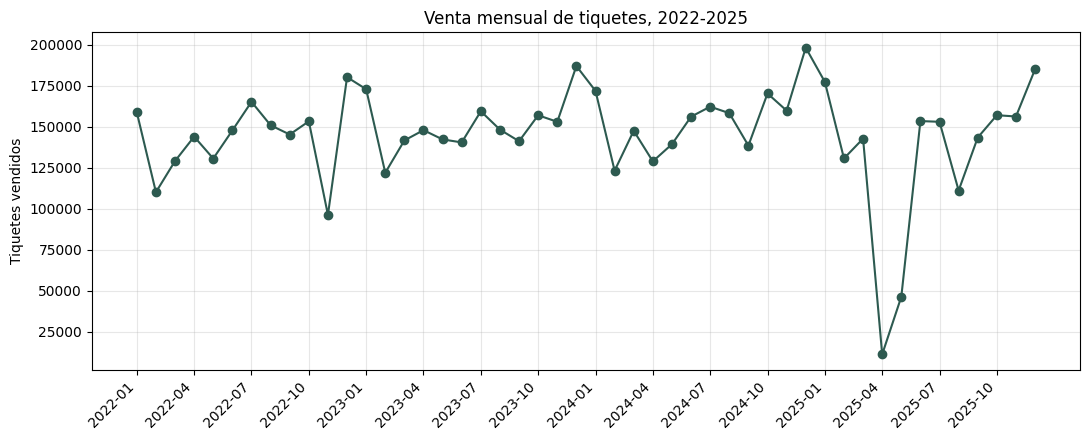

Mes con MAS venta  : 2024-12 198,232
Mes con MENOS venta: 2025-04 11,191


In [7]:
# Juntar todas las agencias y sumar por mes
mensual = panel.groupby('periodo').agg(tiquetes=('tiquetes','sum')).reset_index()

plt.plot(mensual.periodo, mensual.tiquetes, 'o-', color=VERDE)   # 'o-' = puntos unidos por linea
plt.xticks(mensual.periodo[::3], rotation=45, ha='right')        # [::3] = una etiqueta de cada 3
plt.ylabel('Tiquetes vendidos')
plt.title('Venta mensual de tiquetes, 2022-2025')
plt.tight_layout(); plt.show()

# idxmax() devuelve la POSICION de la fila con el valor mas alto
print('Mes con MAS venta  :', mensual.loc[mensual.tiquetes.idxmax(),'periodo'],
      f'{mensual.tiquetes.max():,}')
print('Mes con MENOS venta:', mensual.loc[mensual.tiquetes.idxmin(),'periodo'],
      f'{mensual.tiquetes.min():,}')

**Cómo se lee la gráfica.** La línea sube y baja con un patrón que se repite: cada diciembre hay
un pico y cada febrero un hueco. Eso es **estacionalidad**, y es la razón por la que más adelante
un modelo va a poder predecir.

Pero lo que salta a la vista es **el hueco de abril y mayo de 2025**. La salida lo confirma:

- Mes con más venta: **diciembre de 2024 con 198.232 tiquetes**.
- Mes con menos venta: **abril de 2025 con 11.191 tiquetes**.

Abril de 2025 vendió el **7,5%** de lo que vendió marzo de ese mismo año. No es un error de datos:
el archivo de origen advierte que fue un periodo sin operación normal. Ese hueco nos va a obligar
a tomar dos decisiones más adelante, y las dos hay que explicarlas.

## Celda 5 · Medir la estacionalidad

Ver el patrón en una gráfica está bien, pero hay que cuantificarlo. Construimos un **índice
estacional**: para cada mes del año calculamos cuánto vende en promedio y lo dividimos por el
promedio general.

- Si un mes da **1,00**, vende exactamente lo del mes típico.
- Si da **1,25**, vende un 25% más.
- Si da **0,80**, vende un 20% menos.

Sacamos abril y mayo de 2025 del cálculo. Si los dejáramos, arrastrarían el promedio de abril y
mayo hacia abajo y el índice diría una mentira sobre esos dos meses.

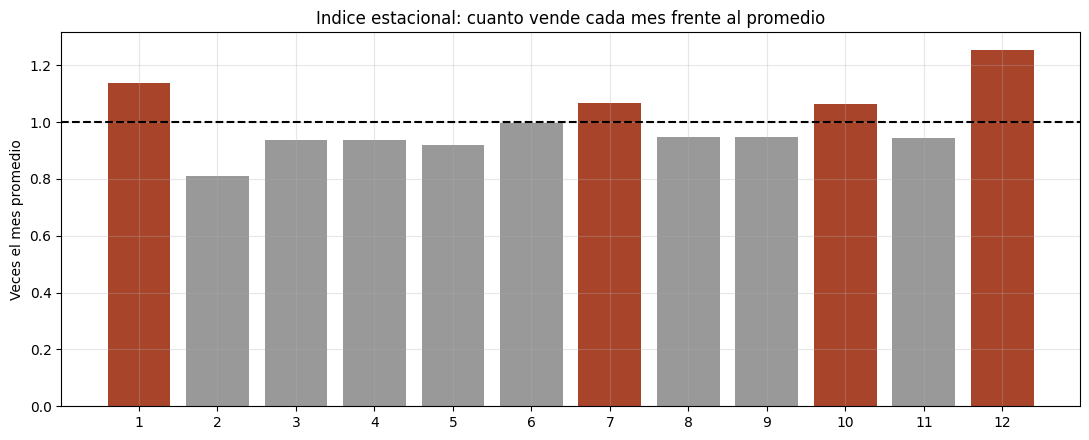

mes
1     1.137
2     0.811
3     0.937
4     0.937
5     0.918
6     0.998
7     1.068
8     0.949
9     0.949
10    1.064
11    0.944
12    1.253


In [8]:
# Quitar los dos meses del paro para que no danen el promedio
normal = mensual[~mensual.periodo.isin(['2025-04','2025-05'])].copy()   # ~ significa "que NO"
normal['mes'] = normal.periodo.str[-2:].astype(int)

# Promedio de cada mes del ano, dividido por el promedio de todos los meses
indice = normal.groupby('mes').tiquetes.mean() / normal.tiquetes.mean()

# Pintar de rojo los meses por encima del promedio y de gris los de abajo
plt.bar(indice.index, indice.values, color=[ROJO if v > 1 else GRIS for v in indice])
plt.axhline(1, ls='--', color='black')      # la linea del mes promedio
plt.xticks(range(1,13))
plt.ylabel('Veces el mes promedio')
plt.title('Indice estacional: cuanto vende cada mes frente al promedio')
plt.tight_layout(); plt.show()

print(indice.round(3).to_string())

**Cómo se lee la salida.**

| Mes | Índice | Traducción |
|---|---|---|
| Diciembre | **1,253** | vende 25% **más** que el mes típico |
| Enero | 1,137 | 14% más |
| Julio | 1,068 | 7% más |
| Octubre | 1,064 | 6% más |
| Junio | 0,998 | igual al promedio |
| **Febrero** | **0,811** | vende 19% **menos** |

El rango va de 0,81 a 1,25: **diciembre vende un 55% más que febrero**. Y esto se repite los
cuatro años, no es casualidad de un año raro.

Para el proyecto esto importa por dos razones. Primera, cualquier modelo que ignore el mes va a
fallar sistemáticamente en diciembre y en febrero. Segunda, y más importante para la
recomendación: **si la demanda cambia 55% entre el mes más alto y el más bajo, la pregunta de
cuánta gente se necesita no tiene una sola respuesta al año, tiene doce.**

## Celda 6 · Qué tan concentrada está la venta

Antes de hablar de agencias en general conviene saber si todas pesan lo mismo. Ordenamos las
agencias de mayor a menor ingreso de 2025 y vamos acumulando hasta llegar al 50% y al 80% del
total.

`cumsum()` va sumando en cadena: la primera fila es ella misma, la segunda es las dos primeras,
la tercera es las tres primeras. Al dividir por el total queda el porcentaje acumulado.

In [9]:
# Ingreso de cada agencia en 2025, de mayor a menor
v2025 = panel[panel.anio == 2025].groupby('sucursal').ingreso.sum().sort_values(ascending=False)

# Porcentaje acumulado: 0.31, 0.57, 0.74... hasta llegar a 1.00
acumulado = v2025.cumsum() / v2025.sum()

print('Agencias con venta en 2025            :', len(v2025))
print('Agencias para llegar al 50% del ingreso:', int((acumulado < 0.50).sum()) + 1)
print('Agencias para llegar al 80% del ingreso:', int((acumulado < 0.80).sum()) + 1)
print()
print('Las 8 mas grandes (millones de pesos, 2025):')
print((v2025.head(8)/1e6).round(0).astype(int).to_string())   # /1e6 pasa de pesos a millones

Agencias con venta en 2025            : 63
Agencias para llegar al 50% del ingreso: 5
Agencias para llegar al 80% del ingreso: 14

Las 8 mas grandes (millones de pesos, 2025):
sucursal
YOPAL                           14710
ARAUCA                          12472
VILLAVICENCIO                    8415
BOGOTA TERMINAL SALITRE P 30     8365
BOGOTA COFLONORTE P 27           6857
TAME                             3807
SARAVENA                         3604
VILLANUEVA                       3242


**Cómo se lee la salida.** De **63 agencias con venta en 2025**:

- **5 agencias hacen el 50%** del ingreso.
- **14 agencias hacen el 80%.**

Es decir que las otras 49 se reparten el 20% restante. Yopal sola facturó **$14.710 millones**,
casi el doble que Villavicencio.

Esta cifra tiene una consecuencia práctica para la recomendación final: **no tiene sentido
aplicarle la misma vara a Yopal y a Támara.** Es la razón por la que en el nivel prescriptivo
vamos a agrupar las agencias antes de compararlas.

## Celda 7 · El hallazgo central

Aquí está el corazón del proyecto, y conviene entender bien la diferencia entre dos conteos que
parecen lo mismo y no lo son.

**Vendedores registrados.** Cuántos usuarios distintos vendieron **al menos un tiquete** en ese
mes en esa agencia. Es lo que uno vería mirando el sistema.

**Vendedores efectivos.** Cuántos hacen falta para acumular el **90% de la venta** de ese mes. Se
calcula ordenando a los vendedores de mayor a menor y contando cuántos se necesitan para llegar
al 90%. Si en una agencia venden 20 personas pero 3 hacen el 90%, hay **3 efectivos**.

Ese cálculo ya viene hecho en el archivo, en la columna `vendedores_efectivos` (se hizo en
`01_preparar_datos.py`, porque necesita el detalle tiquete por tiquete).

Filtramos a las agencias con al menos 10 meses de operación en 2025 y 300 tiquetes al mes, para
no sacar conclusiones de agencias que apenas abrieron o que casi no venden.

AGENCIAS ANALIZADAS: 45

  Vendedores REGISTRADOS en el sistema: 585
  Vendedores EFECTIVOS (hacen el 90%) : 235
  Diferencia                          : 350 (60%)


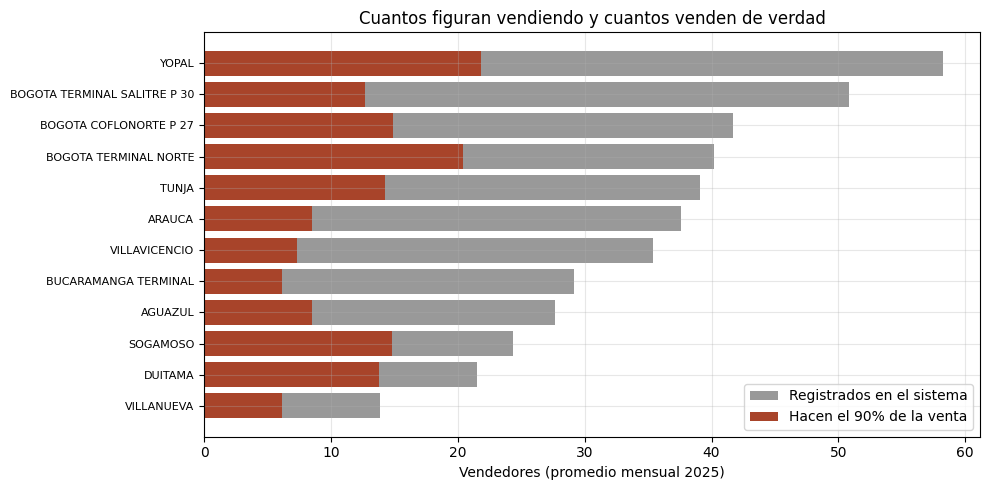

In [10]:
ventas_2025 = panel[panel.anio == 2025]   # nos quedamos con el ano mas reciente

# Promedio mensual de cada agencia en 2025
agencias = ventas_2025.groupby('sucursal').agg(
    tiquetes_mes = ('tiquetes','mean'),                 # cuanto vende al mes
    registrados  = ('vendedores_registrados','mean'),   # cuantos figuran vendiendo
    efectivos    = ('vendedores_efectivos','mean'),     # cuantos hacen el 90%
    meses        = ('periodo','nunique'))               # en cuantos meses opero

# Dejar fuera agencias que apenas operaron o que casi no venden
agencias = agencias[(agencias.meses >= 10) & (agencias.tiquetes_mes >= 300)]

# Productividad: cuantos tiquetes hace cada vendedor efectivo al mes
agencias['productividad'] = agencias.tiquetes_mes / agencias.efectivos

print('AGENCIAS ANALIZADAS:', len(agencias))
print()
print('  Vendedores REGISTRADOS en el sistema:', round(agencias.registrados.sum()))
print('  Vendedores EFECTIVOS (hacen el 90%) :', round(agencias.efectivos.sum()))
print('  Diferencia                          :',
      round(agencias.registrados.sum() - agencias.efectivos.sum()),
      f'({100*(1-agencias.efectivos.sum()/agencias.registrados.sum()):.0f}%)')

# Grafica de barras: las 12 agencias con mas usuarios registrados.
# La barra gris (registrados) se dibuja primero y la roja (efectivos) encima,
# asi que lo que sobresale en gris es la diferencia entre figurar y trabajar.
comparar = agencias.sort_values('registrados', ascending=False).head(12)
posiciones = np.arange(len(comparar))
plt.figure(figsize=(10,5))
plt.barh(posiciones, comparar.registrados, color=GRIS, label='Registrados en el sistema')
plt.barh(posiciones, comparar.efectivos,   color=ROJO, label='Hacen el 90% de la venta')
plt.yticks(posiciones, comparar.index, fontsize=8)
plt.gca().invert_yaxis()             # la mas grande arriba
plt.xlabel('Vendedores (promedio mensual 2025)')
plt.title('Cuantos figuran vendiendo y cuantos venden de verdad')
plt.legend(); plt.tight_layout(); plt.show()

**Cómo se lee la salida.** Sobre **45 agencias**:

- **585 usuarios registrados** vendiendo tiquetes.
- **235 vendedores efectivos** hacen el 90% de la venta.
- **Diferencia: 350 personas, el 60%.**

En la gráfica cada barra gris es cuánta gente figura vendiendo y la roja cuánta hace el trabajo.
El pedazo gris que sobresale es la brecha.

**Qué significa esto y qué NO significa.** `vendedor` es un **usuario del sistema**, no
necesariamente un empleado de nómina. Los 350 pueden ser inspectores que emiten algún tiquete,
supervisores, personal de otra área o credenciales compartidas. Por eso el hallazgo tiene dos
lecturas y las dos le interesan a la empresa:

1. **Si son empleados**, hay personal cuya carga no justifica su puesto.
2. **Si no lo son**, hay 350 usuarios con permiso para emitir tiquetes que casi no emiten, y eso
   es una observación de **control de accesos**: en auditoría, un usuario con un permiso que no
   usa es un riesgo, no una comodidad.

Cuál de las dos es, lo tiene que decir Talento Humano. Nosotros lo dejamos planteado con el
número encima de la mesa.

---
# NIVEL 2 · DIAGNÓSTICA — ¿Por qué pasó?

> En clase quedó dicho: *"si te preguntas el porqué, es diagnóstico"*, y también que
> *"cada vez que estemos buscando correlacionar variables, ya estamos en un análisis
> diagnóstico."*

Ya sabemos **qué** pasó: hay 585 usuarios y 235 hacen el trabajo. Ahora hay que entender **por
qué**, porque de la respuesta depende qué se puede recomendar.

## Celda 8 · Qué tan distinta es la productividad entre agencias

Calculamos, para cada agencia, cuántos tiquetes hace cada vendedor efectivo al mes. Y miramos el
promedio **y la mediana**, que es justo lo que insistió el profesor en la última clase:

> *"Si el valor de la factura empieza a moverse, miren lo que pasa con la media y con la
> mediana... ese tipo de datos lo que hacen es que me arrastran la media. ¿Cuál utilizo? La
> mediana."*

PRODUCTIVIDAD: tiquetes por vendedor efectivo al mes
  Promedio: 588
  Mediana : 477
  Minimo  : 48 -> BOGOTA TERMINAL NORTE
  Maximo  : 2135 -> HATO COROZAL
  La mas productiva rinde 45 veces la menos productiva


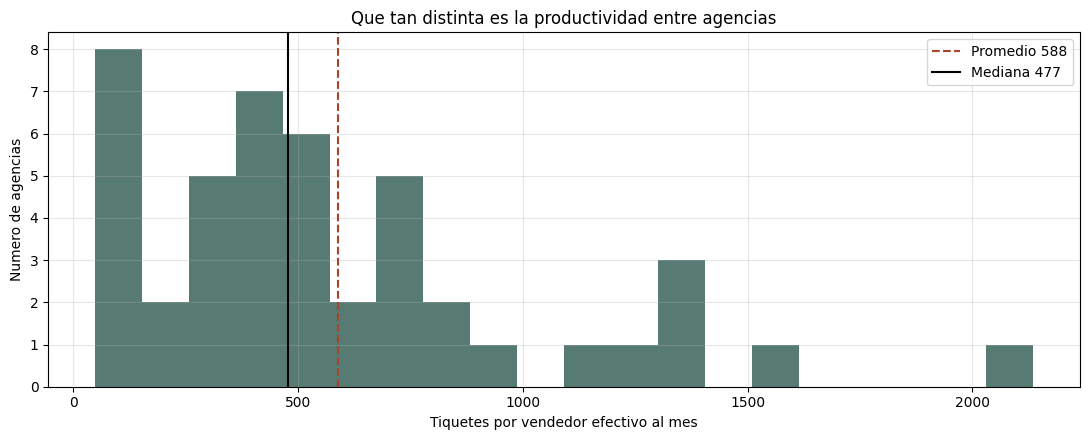

In [11]:
print('PRODUCTIVIDAD: tiquetes por vendedor efectivo al mes')
print('  Promedio:', round(agencias.productividad.mean()))     # se deja arrastrar por extremos
print('  Mediana :', round(agencias.productividad.median()))   # parte los datos por la mitad
print('  Minimo  :', round(agencias.productividad.min()), '->', agencias.productividad.idxmin())
print('  Maximo  :', round(agencias.productividad.max()), '->', agencias.productividad.idxmax())
print('  La mas productiva rinde',
      round(agencias.productividad.max()/agencias.productividad.min()),
      'veces la menos productiva')

# Histograma: cuantas agencias caen en cada rango de productividad
plt.hist(agencias.productividad, bins=20, color=VERDE, alpha=0.8)
plt.axvline(agencias.productividad.mean(),   color=ROJO,   ls='--',
            label=f'Promedio {agencias.productividad.mean():.0f}')
plt.axvline(agencias.productividad.median(), color='black', ls='-',
            label=f'Mediana {agencias.productividad.median():.0f}')
plt.xlabel('Tiquetes por vendedor efectivo al mes')
plt.ylabel('Numero de agencias')
plt.title('Que tan distinta es la productividad entre agencias')
plt.legend(); plt.tight_layout(); plt.show()

**Cómo se lee la salida.**

- **Promedio 588, mediana 477.** El promedio está 111 tiquetes por encima de la mediana. Eso es
  exactamente lo que explicó el profesor: hay unas pocas agencias muy productivas jalando el
  promedio hacia arriba, y por eso **la mediana describe mejor a la agencia típica**. De aquí en
  adelante usamos mediana.
- **Mínimo 48, en Bogotá Terminal Norte.** Cada vendedor efectivo de esa agencia hace 48 tiquetes
  al mes. Son unos **dos tiquetes por día hábil**.
- **Máximo 2.135, en Hato Corozal.** Ahí una sola persona mueve más de dos mil tiquetes al mes.
- **45 veces de diferencia** entre la más y la menos productiva.

En la gráfica, la línea negra es la mediana y la roja punteada el promedio. Se ve que el promedio
queda a la derecha, empujado por la cola de agencias muy productivas.

**Por qué esto importa.** Una diferencia de 45 veces no se explica por el esfuerzo de las
personas. Se explica porque **el número de vendedores de cada agencia no se decidió mirando su
demanda**. Esa es la hipótesis, y la comprobamos en la celda siguiente.

## Celda 9 · ¿La plantilla responde a la demanda?

Si la empresa asignara vendedores según lo que vende cada agencia, entonces demanda y número de
vendedores tendrían que moverse juntos: una agencia que vende el doble debería tener el doble de
gente. Eso se mide con la **correlación**, que va de 0 (ninguna relación) a 1 (relación perfecta).

Usamos escala logarítmica en el eje horizontal porque las agencias son de tamaños muy distintos
—de 300 a 28.000 tiquetes al mes— y en escala normal todas las pequeñas quedarían apiladas contra
el borde izquierdo.

Correlacion demanda ~ vendedores REGISTRADOS: 0.712
Correlacion demanda ~ vendedores EFECTIVOS  : 0.618


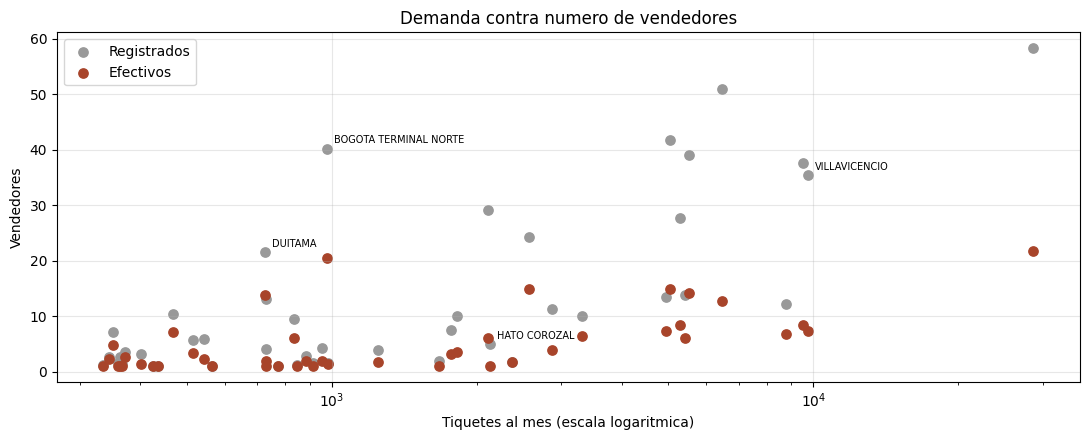

In [12]:
print('Correlacion demanda ~ vendedores REGISTRADOS:',
      round(agencias.tiquetes_mes.corr(agencias.registrados), 3))
print('Correlacion demanda ~ vendedores EFECTIVOS  :',
      round(agencias.tiquetes_mes.corr(agencias.efectivos), 3))

plt.scatter(agencias.tiquetes_mes, agencias.registrados, s=45, color=GRIS, label='Registrados')
plt.scatter(agencias.tiquetes_mes, agencias.efectivos,   s=45, color=ROJO, label='Efectivos')

# Senalar con su nombre los cuatro casos extremos, para poder hablar de ellos
for nombre in ['BOGOTA TERMINAL NORTE','DUITAMA','HATO COROZAL','VILLAVICENCIO']:
    if nombre in agencias.index:
        fila = agencias.loc[nombre]
        plt.annotate(nombre, (fila.tiquetes_mes, fila.registrados), fontsize=7,
                     xytext=(5,4), textcoords='offset points')

plt.xscale('log')          # escala logaritmica: cada paso multiplica por 10
plt.xlabel('Tiquetes al mes (escala logaritmica)')
plt.ylabel('Vendedores')
plt.title('Demanda contra numero de vendedores')
plt.legend(); plt.tight_layout(); plt.show()

**Cómo se lee la salida.**

- Correlación con **registrados: 0,712**.
- Correlación con **efectivos: 0,618**.

Ninguna de las dos llega a 1. Si la asignación de personal siguiera a la demanda, esos números
estarían por encima de 0,9 y los puntos caerían sobre una línea.

Es interesante que la correlación sea **más alta con los registrados que con los efectivos**. Eso
dice que el número de usuarios con acceso al sistema sí crece con el tamaño de la agencia —a
agencia más grande, más gente con clave— pero **el trabajo real se concentra en unos pocos sin
importar cuántos accesos haya**.

En la gráfica, los cuatro nombres marcados son los casos que rompen el patrón. Bogotá Terminal
Norte está muy arriba a la izquierda: vende poco y tiene muchísimos usuarios. Villavicencio está
abajo a la derecha: vende muchísimo con pocos efectivos.

**La conclusión del diagnóstico**, y es la que autoriza todo lo que sigue: la plantilla no
responde a la demanda. Entonces la pregunta correcta no es "¿cuánta gente hay?" sino **"¿cuánta
debería haber, dado lo que cada agencia va a vender?"**. Y para contestar eso hay que predecir la
venta. Ese es el nivel 3.

## Celda 10 · Tres hallazgos de estructura

El nivel diagnóstico no se agota en explicar la productividad. Antes de modelar hay que buscar
**estructura**: relaciones que no son líneas rectas, columnas que dicen lo mismo, y momentos en que
los datos dejan de comportarse como venían. Aquí van los tres que encontramos.

HALLAZGO 1 · crecer deja de comprar productividad
tamano
pequenas       319.0
medianas       477.0
grandes        682.0
muy grandes    666.0

HALLAZGO 2 · columnas que dicen casi lo mismo
  correlacion tiquetes ~ tiquetes_ok: 1.0
  correlacion tiquetes ~ ingreso    : 0.8689

HALLAZGO 3 · la tasa de anulacion se desploma en octubre de 2024
  enero-septiembre 2024   : 0.45%
  octubre 2024-marzo 2025 : 0.08%
  caida                   : 83%
  agencias grandes que bajaron: 29 de 29


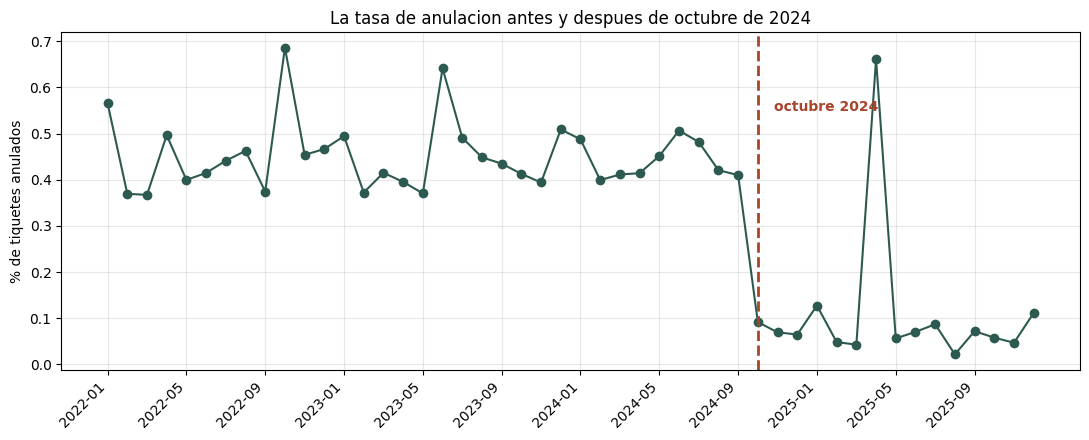

In [13]:
# ---------------------------------------------------------------------
# HALLAZGO 1 · La relacion tamano-productividad NO es una linea recta
# ---------------------------------------------------------------------
por_agencia = panel[panel.anio == 2025].groupby('sucursal').agg(
    tiquetes=('tiquetes','mean'), efectivos=('vendedores_efectivos','mean'),
    meses=('periodo','nunique'))
por_agencia = por_agencia[(por_agencia.meses >= 10) & (por_agencia.tiquetes >= 300)]
por_agencia['rendimiento'] = por_agencia.tiquetes / por_agencia.efectivos

# Partimos las agencias en 4 grupos de igual tamano, de la mas pequena a la mas grande
por_agencia['tamano'] = pd.qcut(por_agencia.tiquetes, 4,
                                labels=['pequenas','medianas','grandes','muy grandes'])

print('HALLAZGO 1 · crecer deja de comprar productividad')
print(por_agencia.groupby('tamano', observed=True).rendimiento.median().round(0).to_string())

# ---------------------------------------------------------------------
# HALLAZGO 2 · Hay columnas que dicen lo mismo
# ---------------------------------------------------------------------
print()
print('HALLAZGO 2 · columnas que dicen casi lo mismo')
print('  correlacion tiquetes ~ tiquetes_ok:',
      round(panel.tiquetes.corr(panel.tiquetes_ok), 4))
print('  correlacion tiquetes ~ ingreso    :',
      round(panel.tiquetes.corr(panel.ingreso), 4))

# ---------------------------------------------------------------------
# HALLAZGO 3 · Un quiebre estructural: la tasa de anulacion
# ---------------------------------------------------------------------
antes   = panel[(panel.periodo >= '2024-01') & (panel.periodo <= '2024-09')]
despues = panel[(panel.periodo >= '2024-10') & (panel.periodo <= '2025-03')]

tasa_antes   = 100 * antes.anulados.sum()   / antes.tiquetes.sum()
tasa_despues = 100 * despues.anulados.sum() / despues.tiquetes.sum()

print()
print('HALLAZGO 3 · la tasa de anulacion se desploma en octubre de 2024')
print(f'  enero-septiembre 2024   : {tasa_antes:.2f}%')
print(f'  octubre 2024-marzo 2025 : {tasa_despues:.2f}%')
print(f'  caida                   : {100*(1-tasa_despues/tasa_antes):.0f}%')

# ¿Bajo una agencia o bajaron todas? Si bajaron todas, no es comportamiento: es sistema.
# Armamos una tablita con una fila por agencia y las dos tasas al lado.
comparar = pd.DataFrame({
    'tiquetes_despues': despues.groupby('sucursal').tiquetes.sum(),
    'tasa_antes'      : 100 * antes.groupby('sucursal').anulados.sum()   / antes.groupby('sucursal').tiquetes.sum(),
    'tasa_despues'    : 100 * despues.groupby('sucursal').anulados.sum() / despues.groupby('sucursal').tiquetes.sum(),
}).dropna()

comparar = comparar[comparar.tiquetes_despues > 5000]      # solo agencias grandes
bajaron  = (comparar.tasa_despues < comparar.tasa_antes).sum()

print(f'  agencias grandes que bajaron: {bajaron} de {len(comparar)}')

# La grafica
tasa_mes = 100 * panel.groupby('periodo').anulados.sum() / panel.groupby('periodo').tiquetes.sum()
plt.plot(tasa_mes.index, tasa_mes.values, 'o-', color=VERDE)
plt.axvline('2024-10', ls='--', color=ROJO, lw=2)
plt.annotate('octubre 2024', ('2024-10', tasa_mes.max()*0.8), color=ROJO, fontsize=10,
             fontweight='bold', xytext=(12,0), textcoords='offset points')
plt.xticks(tasa_mes.index[::4], rotation=45, ha='right')
plt.ylabel('% de tiquetes anulados')
plt.title('La tasa de anulacion antes y despues de octubre de 2024')
plt.tight_layout(); plt.show()

**Cómo se leen los tres.**

**Hallazgo 1 · la relación no es lineal.** La correlación entre tamaño y productividad es 0,441 en
escala normal y sube a **0,533 en logaritmos**: si la relación fuera una recta, las dos serían
iguales. Y por cuartiles se ve la forma: la productividad mediana sube de **319 a 477 y a 682**…
y en el cuartil más grande **se estanca en 666**. Hay rendimientos decrecientes: crecer deja de
comprar productividad a partir de cierto tamaño.

Esto tiene una consecuencia directa sobre el modelo: **una regresión lineal no puede capturar una
curva que primero sube y luego se aplana**. Es uno de los argumentos por los que probamos también
un bosque.

**Hallazgo 2 · hay columnas que dicen lo mismo.** `tiquetes` (los emitidos) y `tiquetes_ok` (los
que viajaron) correlacionan **1,0000**. Y tiene explicación contable: solo se anula el 0,34% de los tiquetes, así que los
emitidos y los que efectivamente viajaron son prácticamente la misma columna. Meter las dos a un
modelo no aporta información, aporta un parámetro más que estimar. Por eso el modelo usa una sola.

**Hallazgo 3 · hay un quiebre estructural en octubre de 2024.** La tasa de anulación venía en
**0,45%** entre enero y septiembre de 2024 y cae a **0,08%** entre octubre y marzo: un **83%
menos**. Y no fue una agencia portándose distinto: **bajaron 29 de las 29 agencias grandes**.

Un cambio así de abrupto y así de transversal no es comportamiento, es **sistema o política**: o
entró un control nuevo, o cambió el procedimiento, o las anulaciones dejaron de registrarse en esa
columna. No podemos decir cuál desde los datos, y por eso queda como pregunta para la empresa.

**Y es el hallazgo que decide el enfoque de todo el proyecto.** Si la tasa de anulación cambió por
sistema y no por comportamiento, entonces **no se puede auditar a las agencias por sus anulaciones**
—la serie no es comparable antes y después— y hay que auditarlas por otra vía: la desviación entre
lo que venden y lo que su plantilla justifica. Que es exactamente lo que hace el resto del cuaderno.

---
# NIVEL 3 · PREDICTIVA — ¿Qué va a pasar?

## Celda 11 · ¿Qué "ayeres" vale la pena mirar? La autocorrelación

Antes de construir el modelo hay que decidir **qué información del pasado le vamos a dar**. Esa
decisión no se toma a ojo: se toma con la **autocorrelación (ACF)**, que mide cuánto se parece la
serie a una copia de sí misma desplazada *k* meses.

> En clase quedó dicho así: *"Desplaza la copia k días y mide cuánto se parecen. Picos en k = 7,
> 14, 21 → estacionalidad semanal."* Y: *"Es la herramienta para elegir rezagos: qué ayeres vale
> la pena meter en el modelo."*

Nuestros datos son mensuales, así que el equivalente de esos picos semanales serían los meses
12 y 24. Vamos a comprobarlo en vez de suponerlo.

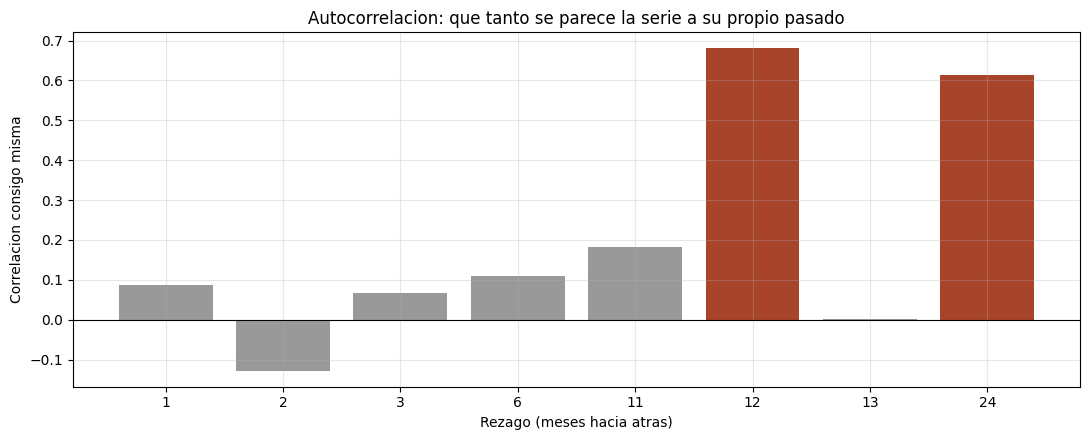

  rezago  1 meses: +0.087
  rezago  2 meses: -0.128
  rezago  3 meses: +0.066
  rezago  6 meses: +0.109
  rezago 11 meses: +0.183
  rezago 12 meses: +0.680
  rezago 13 meses: +0.003
  rezago 24 meses: +0.615


In [14]:
# Serie total mensual, quitando los meses que no son comparables
total = panel.groupby('periodo').tiquetes.sum()
total = total[~total.index.isin(['2025-04','2025-05','2025-08'])]

rezagos = [1, 2, 3, 6, 11, 12, 13, 24]
# autocorr(k) = correlacion de la serie consigo misma desplazada k meses
valores = [total.autocorr(k) for k in rezagos]

plt.bar([str(r) for r in rezagos], valores,
        color=[ROJO if abs(v) > 0.4 else GRIS for v in valores])
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('Rezago (meses hacia atras)')
plt.ylabel('Correlacion consigo misma')
plt.title('Autocorrelacion: que tanto se parece la serie a su propio pasado')
plt.tight_layout(); plt.show()

for r, v in zip(rezagos, valores):
    print(f'  rezago {r:2d} meses: {v:+.3f}')

**Cómo se lee la salida.** El resultado no deja lugar a dudas:

| Rezago | Correlación | |
|---|---|---|
| 1 mes | +0,087 | prácticamente nada |
| 2 meses | −0,128 | nada |
| 6 meses | +0,109 | nada |
| 11 meses | +0,183 | poco |
| **12 meses** | **+0,680** | **fuerte** |
| 13 meses | +0,003 | nada |
| **24 meses** | **+0,615** | **fuerte** |

**Lo que vendió una agencia el mes pasado casi no dice nada sobre lo que va a vender este mes.**
Lo que sí dice es lo que vendió **hace exactamente un año**, y también hace dos.

Eso tiene sentido en el negocio: un diciembre no se parece al noviembre anterior, se parece al
diciembre anterior. Y es la justificación —con evidencia, no con intuición— de por qué el modelo
va a usar el rezago de 12 meses y no el de 1.

También explica por qué el promedio de los últimos 12 meses es una buena segunda variable: al
promediar un año completo, la estacionalidad se cancela y queda el **nivel** de la agencia.

## Celda 12 · Convertir la serie en una tabla de aprendizaje

Este es el paso conceptual clave. Un modelo de regresión no entiende de tiempo: solo sabe estimar
un número a partir de otros números. Hay que **traducirle el tiempo a columnas**.

> El profesor lo llamó *"el puente de vuelta al módulo 1"*, y dio la regla práctica: *"ARIMA
> brilla con series cortas y regulares. Con muchas series o muchas variables externas, el enfoque
> de rezagos + ML suele ganar."* Nosotros tenemos 48 series, una por agencia: caemos justo en ese
> caso.

Las tres variables:

| Variable | Qué es | Por qué |
|---|---|---|
| `mismo_mes_ano_pasado` | lo que vendió 12 meses antes | es el rezago que la ACF señaló |
| `promedio_ultimos_12` | promedio de sus últimos 12 meses | el nivel de la agencia, sin estacionalidad |
| `mes` | número del mes (1 a 12) | permite afinar diciembre y febrero |

`shift(12)` corre la columna 12 posiciones: en enero de 2023 queda el valor de enero de 2022.
`rolling(12).mean()` promedia los últimos 12 valores. Los dos se aplican **por agencia**, para no
mezclar historias.

**Una advertencia que el profesor marcó como error clásico:** *"features con datos futuros"*. Por
eso el promedio lleva `shift(1)` antes del `rolling`: para que el promedio del mes actual **no se
incluya a sí mismo**. Si no, el modelo estaría viendo la respuesta.

Tres decisiones más que hay que poder defender: solo agencias con 44 de los 48 meses y mediana de
150 tiquetes; los meses sin venta se rellenan con 0 porque un mes sin venta es información, no un
faltante; y se pierde todo 2022 porque no tiene "año pasado" con qué compararse.

In [15]:
# --- 1. Agencias con historia suficiente ----------------------------
estables = panel.groupby('sucursal').agg(meses=('periodo','nunique'),
                                         tiquetes=('tiquetes','median'))
estables = estables[(estables.meses >= 44) & (estables.tiquetes >= 150)].index

# --- 2. Rejilla completa agencia x mes, sin huecos -------------------
meses_todos = sorted(panel.periodo.unique())
serie = (pd.MultiIndex.from_product([estables, meses_todos], names=['sucursal','periodo'])
           .to_frame(index=False)
           .merge(panel, on=['sucursal','periodo'], how='left'))
serie['tiquetes'] = serie.tiquetes.fillna(0)          # mes sin venta = 0
serie = serie.sort_values(['sucursal','periodo'])     # ordenar ANTES de los rezagos
serie['mes']  = serie.periodo.str[-2:].astype(int)
serie['anio'] = serie.periodo.str[:4].astype(int)

# --- 3. Las variables que miran hacia atras --------------------------
grupo = serie.groupby('sucursal')

serie['mismo_mes_ano_pasado'] = grupo.tiquetes.shift(12)

# shift(1) ANTES del rolling: el promedio no puede incluir el mes que se predice
serie['promedio_ultimos_12'] = grupo.tiquetes.shift(1).rolling(12).mean().reset_index(0, drop=True)

serie = serie.dropna(subset=['mismo_mes_ano_pasado','promedio_ultimos_12'])

print('Agencias con historia suficiente:', len(estables))
print('Filas listas para el modelo     :', len(serie), '(desde', serie.periodo.min(), ')')
print()
print(serie[serie.sucursal=='YOPAL'][['periodo','tiquetes','mismo_mes_ano_pasado',
                                      'promedio_ultimos_12','mes']].head(4).to_string(index=False))

Agencias con historia suficiente: 48
Filas listas para el modelo     : 1728 (desde 2023-01 )

periodo  tiquetes  mismo_mes_ano_pasado  promedio_ultimos_12  mes
2023-01   32863.0               30894.0         30295.416667    1
2023-02   26045.0               22301.0         30459.500000    2
2023-03   31369.0               26913.0         30771.500000    3
2023-04   33663.0               31028.0         31142.833333    4


**Cómo se lee la salida.** Quedan **48 agencias** y **1.728 filas** (48 × 36 meses, de enero de
2023 a diciembre de 2025).

La tabla de Yopal muestra cómo quedó cada fila:

| periodo | tiquetes | mismo_mes_ano_pasado | promedio_ultimos_12 | mes |
|---|---|---|---|---|
| 2023-01 | 32.863 | 30.894 | 30.295 | 1 |

**En enero de 2023 Yopal vendió 32.863; en enero de 2022 había vendido 30.894; y su promedio de
los doce meses anteriores era 30.295.** El modelo ve las tres últimas columnas y debe estimar la
segunda. Las tres entradas usan solo información anterior a ese mes.

## Celda 13 · Partir por tiempo, y sacar los meses que no son comparables

En el taller de quiebras partimos al azar. **Aquí sería un error grave**, y el profesor lo puso
como el primero de los errores clásicos de series: *"barajar"*.

> *"Si barajas, el modelo 've' el 15 de marzo cuando le preguntas por el 14. Eso es fuga de
> información: en la vida real el futuro no está disponible."*

Entrenamos con 2023 y 2024, y probamos con 2025.

**Tres meses de 2025 se sacan de la evaluación, y las razones son distintas:**

- **Abril y mayo de 2025:** la operación estuvo detenida. Pasó de 148.732 tiquetes en marzo a
  11.191 en abril. Evaluar un modelo de demanda contra un paro no mide si el modelo es bueno.
- **Agosto de 2025:** el archivo de origen advierte que **el ERP no entregó los días 1 al 10**.
  No es que se haya vendido menos: es que faltan diez días de datos. Se comprueba en la celda
  siguiente.

Sacar un mes de la evaluación por conveniencia sería trampa. Sacarlo porque la fuente documenta
que está incompleto es lo correcto, y hay que dejarlo escrito.

In [16]:
VARIABLES = ['mismo_mes_ano_pasado','promedio_ultimos_12','mes']

# Meses de 2025 que NO sirven para evaluar, y por que
EXCLUIR = ['2025-04',   # operacion detenida
           '2025-05',   # operacion detenida
           '2025-08']   # el ERP no entrego los dias 1-10

entrenamiento = serie[serie.anio <= 2024]
prueba        = serie[(serie.anio == 2025) & (~serie.periodo.isin(EXCLUIR))]

print('Entrenamiento (2023-2024):', len(entrenamiento), 'filas')
print('Prueba        (2025)     :', len(prueba), 'filas,', prueba.periodo.nunique(), 'meses')
print()

# Comprobar que agosto 2025 esta realmente incompleto:
# comparar todos los agostos de la serie
agostos = panel[panel.periodo.str.endswith('-08')].groupby('periodo').tiquetes.sum()
print('COMPROBACION DE AGOSTO:')
print(agostos.to_string())
print(f'  agosto 2025 es el {100*agostos["2025-08"]/agostos[:-1].mean():.0f}% del promedio de los anteriores')
print('  faltan 10 de 31 dias = 32% -> el faltante observado (27%) coincide con lo documentado')

Entrenamiento (2023-2024): 1152 filas
Prueba        (2025)     : 432 filas, 9 meses

COMPROBACION DE AGOSTO:
periodo
2022-08    150914
2023-08    148254
2024-08    158293
2025-08    111110
  agosto 2025 es el 73% del promedio de los anteriores
  faltan 10 de 31 dias = 32% -> el faltante observado (27%) coincide con lo documentado


**Cómo se lee la salida.** **1.152 filas de entrenamiento** y **432 de prueba**, que son 48
agencias por 9 meses de 2025.

Y la comprobación de agosto es concluyente:

| Periodo | Tiquetes |
|---|---|
| 2022-08 | 150.914 |
| 2023-08 | 148.254 |
| 2024-08 | 158.293 |
| **2025-08** | **111.110** |

Agosto de 2025 vendió el **73%** del promedio de los agostos anteriores. Le falta el 27%. El
archivo de origen dice que el ERP no entregó los días 1 al 10, que son **10 de 31 días, el 32%**.
Las dos cifras coinciden dentro de lo razonable.

**Esto no es un problema del negocio, es un problema de la fuente**, y encontrarlo es parte del
trabajo. Si no lo hubiéramos detectado, el modelo aparecería equivocándose un 38% en agosto y
habríamos concluido que no sirve.

## Celda 14 · Tres modelos compitiendo

El enunciado exige **dos o más modelos distintos**, y advierte que dos regresiones con distintas
variables no son dos modelos. Aquí compiten tres cosas de naturaleza diferente:

**La línea base: repetir lo del año pasado.** El *naive estacional*. No es un modelo, es la regla
de sentido común. El profesor fue explícito: *"cualquier modelo sofisticado debe ganarle al naive
estacional. Muchos no lo logran. Siempre reportar la mejora sobre él."*

**Regresión lineal.** Aprende una fórmula. Transparente, pero supone una línea recta.

**Bosque aleatorio.** 200 árboles votando. Flexible, pero no se puede escribir en una fórmula.

Las métricas son las cuatro que enseñó la clase, más una columna de control:

| Medida | Qué es |
|---|---|
| `MAE` | error promedio en tiquetes |
| `R2` | qué porcentaje de la variación explica |
| `error_%` | el MAE como porcentaje de la venta promedio |
| **`MASE`** | **MAE del modelo ÷ MAE del naive. Menor que 1 = le gano al tonto** |
| `imposibles` | cuántas veces predijo una venta negativa |

El **MASE** es la que más importa aquí, porque responde directamente a la exigencia del profesor:
no basta con tener buen error, hay que **ganarle a la regla tonta**.

In [17]:
# El MAE del modelo tonto es la vara: contra ese se compara todo
mae_naive = mean_absolute_error(prueba.tiquetes, prueba.mismo_mes_ano_pasado)

def evaluar(nombre, real, prediccion):
    mae = mean_absolute_error(real, prediccion)
    return {'modelo': nombre,
            'MAE': round(mae),
            'R2': round(r2_score(real, prediccion), 3),
            'error_%': round(100*mae/real.mean(), 1),
            'MASE': round(mae/mae_naive, 3),      # < 1 significa que le gana al tonto
            'imposibles': int((prediccion < 0).sum())}

resultados = []

# --- Modelo 0: naive estacional (la vara) ---------------------------
resultados.append(evaluar('Naive estacional (la vara)',
                          prueba.tiquetes, prueba.mismo_mes_ano_pasado))

# --- Modelo 1: regresion lineal -------------------------------------
lineal = LinearRegression().fit(entrenamiento[VARIABLES], entrenamiento.tiquetes)
resultados.append(evaluar('Regresion lineal', prueba.tiquetes, lineal.predict(prueba[VARIABLES])))

# --- Modelo 2: bosque aleatorio -------------------------------------
#   n_estimators=200   -> 200 arboles
#   random_state=42    -> fija el azar (plantar la semilla)
#   min_samples_leaf=5 -> ninguna hoja con menos de 5 casos, para que no memorice
bosque = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_leaf=5)
bosque.fit(entrenamiento[VARIABLES], entrenamiento.tiquetes)
resultados.append(evaluar('Bosque aleatorio', prueba.tiquetes, bosque.predict(prueba[VARIABLES])))

print(pd.DataFrame(resultados).to_string(index=False))
print()
print('La formula que aprendio la regresion lineal:')
for nombre, coef in zip(VARIABLES, lineal.coef_):
    print(f'   {nombre:24s} x {coef:+.3f}')
print(f'   {"punto de partida":24s}   {lineal.intercept_:+.0f}')

                    modelo  MAE    R2  error_%  MASE  imposibles
Naive estacional (la vara)  516 0.929     16.9 1.000           0
          Regresion lineal  436 0.960     14.3 0.844           7
          Bosque aleatorio  416 0.959     13.6 0.805           0

La formula que aprendio la regresion lineal:
   mismo_mes_ano_pasado     x +0.544
   promedio_ultimos_12      x +0.521
   mes                      x +28.667
   punto de partida           -296


**Cómo se lee la salida.**

| modelo | MAE | R² | error_% | MASE | imposibles |
|---|---|---|---|---|---|
| Naive estacional (la vara) | 516 | 0,929 | 16,9 | 1,000 | 0 |
| Regresión lineal | 436 | 0,960 | 14,3 | 0,844 | **7** |
| **Bosque aleatorio** | **416** | 0,959 | **13,6** | **0,805** | **0** |

**La vara ya es alta.** Repetir lo del año pasado explica el 92,9% de la variación. Eso confirma
lo fuerte que es la estacionalidad, y es la razón por la que el profesor insiste en calcularla:
sin ella uno vería un R² de 0,96 y creería que hizo algo extraordinario.

**El MASE es la cifra que hay que citar.** El bosque tiene **MASE 0,805**: comete el 80,5% del
error del modelo tonto, es decir **le recorta el error un 19,5%**. La lineal se queda en 0,844.
Los dos le ganan al tonto, que es el requisito mínimo.

**Y el hallazgo para la sustentación:** la regresión lineal produce **7 predicciones negativas**
—dice que una agencia venderá menos de cero tiquetes—. Pasa porque una recta no tiene piso. **Es
exactamente lo que vimos en la Pregunta 11 del taller de quiebras con la probabilidad de −0,24.**
El bosque nunca lo hace, porque cada árbol solo puede predecir promedios de casos reales.

Ese es el "qué se pierde con esa elección" que exige el enunciado: la lineal tiene un R² un
milésimo mejor y es más explicable, pero produce valores que no existen. **Escogemos el bosque.**

**La fórmula de la lineal** vale la pena leerla porque se cuenta en una frase:

```
venta prevista = 0,544 x (lo del mismo mes del año pasado)
               + 0,521 x (el promedio del último año)
               + 28,7  x (el número del mes)
               - 296
```

Es decir: **mitad memoria estacional, mitad nivel actual.** Que los dos coeficientes sean casi
iguales dice que las dos señales pesan lo mismo.

## Celda 15 · Validación con ventana deslizante

Un solo corte en el tiempo prueba el modelo contra **un** futuro. ¿Y si 2025 fue un año fácil?

La clase enseñó la respuesta: **la ventana deslizante**, que es la versión temporal de la
validación cruzada.

> *"Entrenar hasta una fecha, probar el siguiente tramo, avanzar. Cada bloque ámbar es un 'futuro'
> distinto."*

Hacemos tres cortes: entrenar hasta junio de 2024 y probar los seis meses siguientes; entrenar
hasta diciembre de 2024 y probar los seis siguientes; entrenar hasta junio de 2025 y probar los
seis siguientes. En cada corte comparamos contra el naive del mismo tramo.

In [18]:
meses = sorted(serie.periodo.unique())
cortes = ['2024-06', '2024-12', '2025-06']
filas = []

for corte in cortes:
    pasado = serie[serie.periodo < corte]                    # lo que el modelo puede ver
    futuro_meses = [m for m in meses if m >= corte][:6]       # los 6 meses siguientes
    futuro = serie[serie.periodo.isin(futuro_meses)]

    modelo = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_leaf=5)
    modelo.fit(pasado[VARIABLES], pasado.tiquetes)

    mae_modelo = mean_absolute_error(futuro.tiquetes, modelo.predict(futuro[VARIABLES]))
    mae_tonto  = mean_absolute_error(futuro.tiquetes, futuro.mismo_mes_ano_pasado)

    filas.append({'entrena_hasta': corte,
                  'prueba': f'{futuro_meses[0]} a {futuro_meses[-1]}',
                  'filas_entrena': len(pasado),
                  'MAE': round(mae_modelo),
                  'MAE_tonto': round(mae_tonto),
                  'MASE': round(mae_modelo/mae_tonto, 2),
                  'tiene_paro': any(m in futuro_meses for m in ['2025-04','2025-05'])})

print(pd.DataFrame(filas).to_string(index=False))

entrena_hasta            prueba  filas_entrena  MAE  MAE_tonto  MASE  tiene_paro
      2024-06 2024-06 a 2024-11            816  544        544  1.00       False
      2024-12 2024-12 a 2025-05           1104 1081       1014  1.07        True
      2025-06 2025-06 a 2025-11           1392  504        637  0.79       False


**Cómo se lee la salida.**

| entrena hasta | prueba | MAE | MAE tonto | MASE | tiene paro |
|---|---|---|---|---|---|
| 2024-06 | 2024-06 a 2024-11 | 544 | 544 | 1,00 | No |
| 2024-12 | 2024-12 a 2025-05 | 1.081 | 1.014 | **1,07** | **Sí** |
| 2025-06 | 2025-06 a 2025-11 | 504 | 637 | **0,79** | No |

Tres lecturas, y las tres sirven para la sustentación.

**Uno: el modelo necesita historia.** En el primer corte solo tenía año y medio de datos y quedó
empatado con el tonto (MASE 1,00). Con tres años ya le gana claramente (0,79).

**Dos: el único corte donde el modelo pierde es el que contiene el paro.** MASE 1,07 significa que
ahí el modelo lo hizo **peor** que repetir el año anterior. No es un defecto del modelo: es la
prueba cuantificada de que abril y mayo de 2025 fueron un evento excepcional. El error se duplica,
de ~500 a 1.081.

**Tres: el resultado es estable fuera de ese evento.** MAE de 544 y 504 en los dos cortes normales,
y 416 en la prueba principal de la celda anterior. No estamos reportando un resultado afortunado.

Esto responde por adelantado a la pregunta *"¿y si 2025 fue un año fácil?"*.

## Celda 16 · El pronóstico contra la realidad, agencia por agencia

Las métricas son promedios de 432 predicciones. Vale la pena mirar **una agencia mes a mes**.

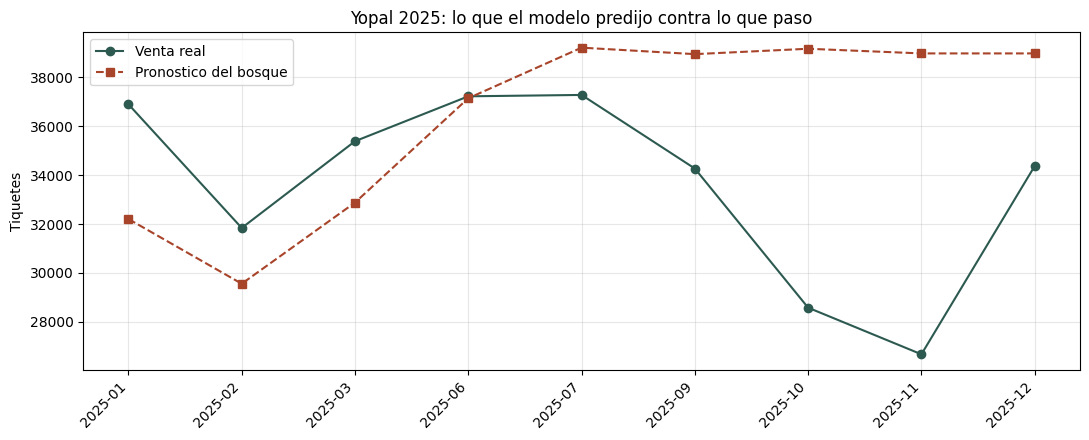

Error promedio en Yopal: 4852 tiquetes al mes
Sobre una venta de 33613 tiquetes -> 14.4 % de error

ERROR DEL TOTAL MENSUAL (que es lo que se lleva al comite):
             real  previsto  error_%
periodo                             
2025-01  174025.0  167403.0      3.8
2025-02  128143.0  135408.0     -5.7
2025-03  137837.0  144751.0     -5.0
2025-06  144716.0  142262.0      1.7
2025-07  144437.0  149677.0     -3.6
2025-09  137243.0  138601.0     -1.0
2025-10  142262.0  149338.0     -5.0
2025-11  141293.0  147781.0     -4.6
2025-12  171011.0  166598.0      2.6

  error medio del total: 3.7%
  peor mes            : 5.7%


In [19]:
# Cambiar 'YOPAL' por cualquier otra agencia para ver su caso
ejemplo = prueba[prueba.sucursal == 'YOPAL'].copy()
ejemplo['pronostico'] = bosque.predict(ejemplo[VARIABLES])

plt.plot(ejemplo.periodo, ejemplo.tiquetes,   'o-',  color=VERDE, label='Venta real')
plt.plot(ejemplo.periodo, ejemplo.pronostico, 's--', color=ROJO,  label='Pronostico del bosque')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Tiquetes')
plt.title('Yopal 2025: lo que el modelo predijo contra lo que paso')
plt.legend(); plt.tight_layout(); plt.show()

error = mean_absolute_error(ejemplo.tiquetes, ejemplo.pronostico)
print('Error promedio en Yopal:', round(error), 'tiquetes al mes')
print('Sobre una venta de', round(ejemplo.tiquetes.mean()), 'tiquetes ->',
      round(100*error/ejemplo.tiquetes.mean(), 1), '% de error')

# El error del TOTAL es mucho menor que el de cada agencia por separado,
# porque los errores de unas y otras se compensan entre si.
prueba_con_pred = prueba.copy()
prueba_con_pred['pronostico'] = bosque.predict(prueba[VARIABLES])
totales = prueba_con_pred.groupby('periodo').agg(real=('tiquetes','sum'),
                                                 previsto=('pronostico','sum'))
totales['error_%'] = (100*(totales.real - totales.previsto)/totales.real).round(1)
totales[['real','previsto']] = totales[['real','previsto']].round(0)
print()
print('ERROR DEL TOTAL MENSUAL (que es lo que se lleva al comite):')
print(totales.to_string())
print()
print(f'  error medio del total: {totales["error_%"].abs().mean():.1f}%')
print(f'  peor mes            : {totales["error_%"].abs().max():.1f}%')

**Cómo se lee la salida.** En Yopal el error es de **4.852 tiquetes al mes sobre una venta de
33.613, un 14,4%**.

Hay que ser honesto con ese 14%: no es poco. Para dimensionar personal alcanza, porque la
diferencia entre 8 y 9 vendedores no se juega en 5.000 tiquetes de 30.000. Para decidir cuántos
buses despachar mañana, no alcanzaría. **Un modelo sirve o no sirve según para qué decisión se
use**, no en abstracto.

**Pero hay un punto importante que se ve en la segunda tabla.** El error del **total mensual** es
mucho menor que el de cada agencia por separado:

| Periodo | Real | Previsto | Error |
|---|---|---|---|
| 2025-01 | 174.025 | 167.403 | +3,8% |
| 2025-02 | 128.143 | 135.408 | −5,7% |
| 2025-12 | 171.011 | 166.598 | +2,6% |

**Error medio del total: 3,7%. El peor mes: 5,7%.**

La razón es estadística: cuando el modelo se pasa en una agencia y se queda corto en otra, los dos
errores se cancelan al sumar. Por eso **el pronóstico agregado es mucho más confiable que el de
una agencia suelta**, y por eso la recomendación de personal se construye sobre el total y no
sobre casos individuales.

## Celda 17 · El pronóstico de 2026, con su intervalo

Ya sabemos que el modelo funciona. Lo reentrenamos con **todo** —2023, 2024 y 2025— y le pedimos
los doce meses de 2026.

**Dos correcciones que hay que declarar.**

*Primera.* Para predecir abril de 2026, la variable `mismo_mes_ano_pasado` sería abril de **2025**,
el mes del paro. Si lo dejáramos, el modelo proyectaría el paro hacia 2026. Para abril y mayo
usamos **2024**. Y para agosto también, porque agosto de 2025 está incompleto.

*Segunda, y es la que el profesor marcó como error clásico:* **"reportar sin intervalos"**.

> *"Un pronóstico de 300 ventas sin rango es una promesa que nadie puede cumplir. El rango es lo
> que permite decidir."*

El intervalo lo calculamos con los errores reales del modelo en 2025, que es la información
honesta que tenemos: el error del total mensual estuvo entre −5,7% y +3,8%. Usamos **±6%**, que
cubre todos los meses observados.

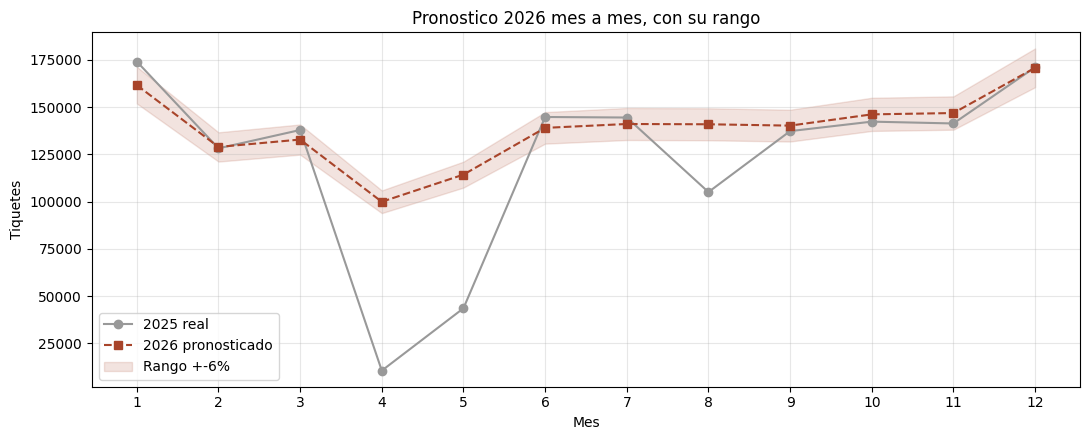

PRONOSTICO 2026
         previsto    piso   techo
periodo                          
2026-01    161560  151866  171253
2026-02    128878  121145  136610
2026-03    132788  124820  140755
2026-04     99886   93892  105879
2026-05    114248  107393  121102
2026-06    138963  130625  147300
2026-07    141014  132553  149474
2026-08    140867  132414  149319
2026-09    140152  131742  148561
2026-10    146104  137337  154870
2026-11    146807  137998  155615
2026-12    170721  160477  180964

Total 2026 previsto: 1,661,988  (entre 1,562,268 y 1,761,707)


In [20]:
# --- Reentrenar con todo lo disponible ------------------------------
modelo_final = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_leaf=5)
modelo_final.fit(serie[VARIABLES], serie.tiquetes)

v2025 = serie[serie.anio == 2025]
v2024 = serie[serie.anio == 2024]
MESES_MALOS = [4, 5, 8]      # paro (abril, mayo) y agosto incompleto
filas = []

for agencia in estables:
    h25 = v2025[v2025.sucursal == agencia]
    h24 = v2024[v2024.sucursal == agencia]
    if len(h25) < 12:
        continue

    # Nivel base: promedio de 2025 SIN los meses malos
    base = h25[~h25.mes.isin(MESES_MALOS)].tiquetes.mean()

    for m in range(1, 13):
        # Para los meses malos se usa 2024 como referencia; para el resto, 2025
        referencia = h24[h24.mes == m] if m in MESES_MALOS else h25[h25.mes == m]
        filas.append({'sucursal': agencia, 'periodo': f'2026-{m:02d}', 'mes': m,
                      'mismo_mes_ano_pasado': referencia.tiquetes.values[0] if len(referencia) else base,
                      'promedio_ultimos_12': base})

pronostico_2026 = pd.DataFrame(filas)
pronostico_2026['tiquetes_previstos'] = modelo_final.predict(pronostico_2026[VARIABLES]).round()

# --- El intervalo, sacado del error observado en 2025 ----------------
BANDA = 0.06     # +-6%: cubre el peor mes de 2025 (5,7%)

resumen = pronostico_2026.groupby('periodo').tiquetes_previstos.sum()
piso  = resumen * (1 - BANDA)
techo = resumen * (1 + BANDA)
real_2025 = serie[serie.anio == 2025].groupby('periodo').tiquetes.sum()

plt.plot(range(1,13), real_2025.values, 'o-', color=GRIS, label='2025 real')
plt.plot(range(1,13), resumen.values, 's--', color=ROJO, label='2026 pronosticado')
plt.fill_between(range(1,13), piso, techo, color=ROJO, alpha=0.15,
                 label=f'Rango +-{BANDA:.0%}')
plt.xticks(range(1,13)); plt.xlabel('Mes'); plt.ylabel('Tiquetes')
plt.title('Pronostico 2026 mes a mes, con su rango')
plt.legend(); plt.tight_layout(); plt.show()

tabla = pd.DataFrame({'previsto': resumen.astype(int),
                      'piso': piso.astype(int),
                      'techo': techo.astype(int)})
print('PRONOSTICO 2026'); print(tabla.to_string())
print()
print(f'Total 2026 previsto: {int(resumen.sum()):,}  '
      f'(entre {int(piso.sum()):,} y {int(techo.sum()):,})')

**Cómo se lee la salida.**

| Mes | Previsto | Piso | Techo |
|---|---|---|---|
| Enero | 161.560 | 151.866 | 171.253 |
| Febrero | 128.878 | 121.145 | 136.610 |
| ... | | | |
| Diciembre | 170.721 | 160.477 | 180.964 |

**Total 2026: alrededor de 1,66 millones de tiquetes, entre 1,56 y 1,76 millones.**

En la gráfica, la banda sombreada es el rango. Es lo que permite decidir: *"para planear el
personal de diciembre usamos el techo; para el presupuesto conservador, el piso."* Eso es
exactamente lo que dijo la clase: *"inventario se planea con el límite superior; presupuesto
conservador con el inferior."*

Diciembre queda como el mes más alto y febrero entre los más bajos, que es el patrón estacional
de la celda 5. El modelo no inventó nada: aprendió el ritmo del negocio.

**Y aquí está el cierre de la sustentación.** El modelo se entrenó con datos hasta diciembre de
2025 y **no vio un solo dato de 2026**. Cuando la empresa tenga los meses corridos, se contrasta
esta tabla contra lo que de verdad pasó. Es una prueba fuera de muestra real, y es lo que
describió el profesor: *"¿para qué hago yo la predicción sobre un conjunto de datos sobre el cual
ya conozco los valores reales? Para ver qué tanto se diferencia."*

---
# NIVEL 4 · PRESCRIPTIVA — ¿Qué hago?

> El enunciado es tajante: *"Predecir no es decidir. Un modelo entrega una probabilidad; la
> organización necesita una lista de qué hacer el lunes."* Y advierte que este es el nivel que más
> se omite y el que más pesa en la nota.

## Celda 18 · ¿Cuántos grupos? El codo y la silueta

Para saber cuántos vendedores necesita una agencia hay que dividir su demanda por una
**productividad de referencia**. ¿Cuál? Una sola vara para todas sería injusta: una agencia con
140 rutas y una con 20 no hacen el mismo trabajo por tiquete.

Aquí entra el **K-means**, que es el modelo **no supervisado**: nadie le dice qué buscar, él
encuentra los grupos naturales.

Pero K-means necesita que le digan **cuántos grupos**, y ese número no viene en los datos. La
clase enseñó las dos herramientas para decidirlo:

**El codo (inercia).** La inercia es la suma de distancias al cuadrado de cada agencia a su centro.
*"La inercia siempre baja al subir K (con K = n es cero). Por eso no se busca el mínimo sino el
codo: donde añadir un grupo ya casi no ayuda."*

**La silueta.** Va de −1 a 1. *"a = distancia media a los de mi grupo; b = al grupo vecino más
cercano. Cerca de 1: bien agrupado. Cerca de 0: en la frontera. Negativo: estoy en el grupo
equivocado."* Se busca el máximo.

Antes de agrupar hay que **estandarizar**, y esto no es opcional: *"si 'ingreso' está en millones
y 'edad' en años, la distancia solo ve el ingreso. Escalar siempre."* Nuestros tiquetes van en
miles y la tarifa en decenas de miles.

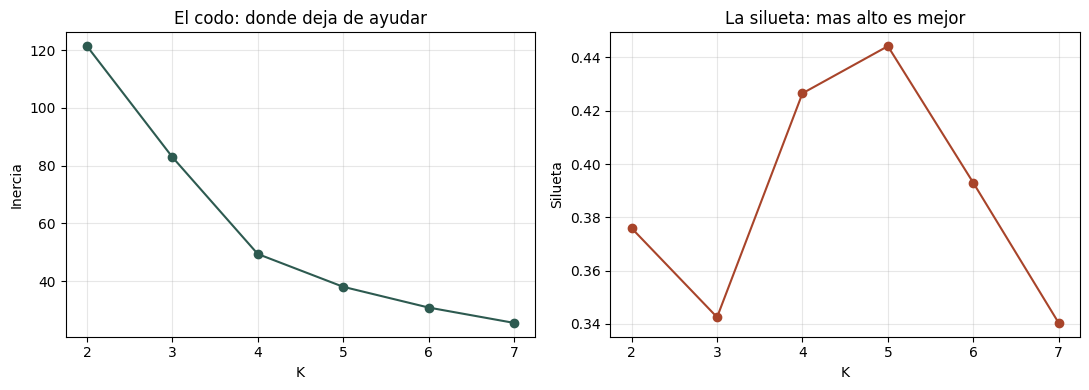

 K  inercia  silueta  grupos_de_una_sola
 2    121.4    0.376                   0
 3     82.9    0.343                   1
 4     49.4    0.427                   1
 5     38.0    0.444                   1
 6     30.8    0.393                   1
 7     25.5    0.340                   1


In [21]:
# --- Perfil de cada agencia en 2025 ---------------------------------
perfil = panel[panel.anio == 2025].groupby('sucursal').agg(
    tiquetes_mes = ('tiquetes','mean'),              # tamano
    tarifa       = ('tarifa_mediana','mean'),        # viaje corto o largo
    trayectos    = ('trayectos','mean'),             # complejidad de la operacion
    efectivos    = ('vendedores_efectivos','mean'),
    registrados  = ('vendedores_registrados','mean'),
    meses        = ('periodo','nunique'))
perfil = perfil[(perfil.meses >= 10) & (perfil.tiquetes_mes >= 300)]
perfil['productividad'] = perfil.tiquetes_mes / perfil.efectivos

# --- Estandarizar: media 0 y desviacion 1 en las cuatro variables ---
perfil_escalado = StandardScaler().fit_transform(
    perfil[['tiquetes_mes','tarifa','trayectos','productividad']])

# --- Probar de 2 a 7 grupos y medir las dos cosas -------------------
ks, inercias, siluetas, singletons = [], [], [], []
for k in range(2, 8):
    agrupador = KMeans(n_clusters=k, random_state=42, n_init=10).fit(perfil_escalado)
    ks.append(k)
    inercias.append(agrupador.inertia_)
    siluetas.append(silhouette_score(perfil_escalado, agrupador.labels_))
    # cuantos grupos quedan con UNA sola agencia (senal de que solo esta aislando raros)
    singletons.append(int((pd.Series(agrupador.labels_).value_counts() == 1).sum()))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(ks, inercias, 'o-', color=VERDE); a1.set_xlabel('K'); a1.set_ylabel('Inercia')
a1.set_title('El codo: donde deja de ayudar')
a2.plot(ks, siluetas, 'o-', color=ROJO);  a2.set_xlabel('K'); a2.set_ylabel('Silueta')
a2.set_title('La silueta: mas alto es mejor')
plt.tight_layout(); plt.show()

print(pd.DataFrame({'K': ks, 'inercia': np.round(inercias,1),
                    'silueta': np.round(siluetas,3),
                    'grupos_de_una_sola': singletons}).to_string(index=False))

**Cómo se lee la salida.**

| K | Inercia | Silueta | Grupos de una sola agencia |
|---|---|---|---|
| 2 | 121,4 | 0,376 | 0 |
| 3 | 82,9 | 0,343 | 1 |
| **4** | **49,4** | **0,427** | 1 |
| 5 | 38,0 | **0,444** | 1 |
| 6 | 30,8 | 0,393 | 1 |
| 7 | 25,5 | 0,340 | 1 |

**El codo está en 4:** de K=3 a K=4 la inercia cae de 82,9 a 49,4, y de ahí en adelante las
caídas son mucho menores.

**La silueta tiene su máximo en 5 (0,444), con 4 muy cerca (0,427).** La diferencia es de 0,017.

**Escogemos K = 4, y hay que poder defenderlo.** Tres razones:

*Primera, la diferencia con K=5 es despreciable*: 0,017 de silueta sobre 45 agencias no es una
señal, es ruido.

*Segunda, y es la de fondo:* el grupo extra que aparece en K=5 son **tres agencias —Hato Corozal,
Trinidad y Yopalosa— que son precisamente las que operan con una sola persona a productividad
extrema**. Si les damos su propio grupo, su vara de referencia pasa a ser su propio comportamiento,
y el modelo concluiría que están bien dimensionadas. **Sería circular:** usaríamos la anomalía que
queremos detectar como la norma con la que se mide.

*Tercera, la que dio el profesor en clase:* *"Ninguna métrica reemplaza la pregunta '¿estos grupos
significan algo para el negocio?'. K = 3 con nombres claros vale más que K = 7 óptimo."* Con K = 4
los cuatro grupos tienen nombre. Se ve en la celda siguiente.

## Celda 19 · Los cuatro grupos y sus nombres

Ahora sí agrupamos con K = 4 y miramos qué encontró el algoritmo.

In [22]:
perfil['grupo'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(perfil_escalado)

print('LOS CUATRO GRUPOS (el algoritmo no sabe nada de transporte)')
print(perfil.groupby('grupo').agg(
    agencias      = ('tiquetes_mes','size'),
    tiquetes_mes  = ('tiquetes_mes','mean'),
    tarifa        = ('tarifa','mean'),
    trayectos     = ('trayectos','mean'),
    productividad = ('productividad','median')).round(0).to_string())
print()
for g in sorted(perfil.grupo.unique()):
    nombres = list(perfil[perfil.grupo == g].index)
    print(f'  Grupo {g} ({len(nombres)} agencias):', ', '.join(nombres[:8]),
          '...' if len(nombres) > 8 else '')

LOS CUATRO GRUPOS (el algoritmo no sabe nada de transporte)
       agencias  tiquetes_mes    tarifa  trayectos  productividad
grupo                                                            
0             9        2256.0  108780.0       29.0          366.0
1            26        1064.0   30731.0       20.0          378.0
2             1       28640.0   30833.0      140.0         1312.0
3             9        5537.0   47162.0       48.0         1283.0

  Grupo 0 (9 agencias): ARAUQUITA, BOGOTA COFLONORTE P 27, BOGOTA TERMINAL NORTE, BOGOTA TERMINAL SALITRE P 30, BUCARAMANGA TERMINAL, CUCUTA, FORTUL, PUEBLO NUEVO ...
  Grupo 1 (26 agencias): BARRANCA DE UPIA, CRAVO NORTE, CUMARAL, DUITAMA, EL VENADO, GARAGOA, JENESANO, MANI ...
  Grupo 2 (1 agencias): YOPAL 
  Grupo 3 (9 agencias): AGUAZUL, ARAUCA, HATO COROZAL, PAZ DE ARIPORO, TAME, TRINIDAD, VILLANUEVA, VILLAVICENCIO ...


**Cómo se lee la salida.**

| Grupo | Agencias | Tiquetes/mes | Tarifa | Trayectos | Productividad |
|---|---|---|---|---|---|
| **0** | 9 | 2.256 | **$108.780** | 29 | 366 |
| **1** | 26 | 1.064 | $30.731 | 20 | 378 |
| **2** | 1 | **28.640** | $30.833 | **140** | 1.312 |
| **3** | 9 | 5.537 | $47.162 | 48 | **1.283** |

**Lo que separa a los grupos es la tarifa, y eso tiene nombre de negocio:**

- **Grupo 0 · Terminales y rutas largas.** Tarifa de $108.780, casi cuatro veces la del grupo 1.
  Son las tres terminales de Bogotá, Bucaramanga, Cúcuta, Saravena, Arauquita, Fortul y Pueblo
  Nuevo: destinos lejanos, tiquete caro, poco volumen por vendedor.
- **Grupo 1 · Agencias locales.** 26 agencias, tarifa de $30.731, mil tiquetes al mes. Duitama,
  Paipa, Garagoa, Sogamoso, Tunja.
- **Grupo 2 · El hub.** Yopal sola: 28.640 tiquetes, 140 rutas distintas, 1.312 tiquetes por
  vendedor. **Yopal no se parece a ninguna otra agencia de la empresa**, y eso ya es un hallazgo.
- **Grupo 3 · Alto volumen del llano.** Aguazul, Arauca, Hato Corozal, Paz de Ariporo, Tame,
  Trinidad, Villanueva, Villavicencio, Yopalosa. Tarifa media, mucho volumen y **la productividad
  más alta después de Yopal: 1.283**.

Esto es lo que el enunciado llama un no supervisado *"que aporte algo que el supervisado no
puede"*: el modelo de pronóstico jamás nos habría dicho que existen cuatro tipos de agencia, ni
que la tarifa es lo que las separa.

## Celda 20 · Cuántos vendedores necesita cada agencia

La cuenta es una división:

> **vendedores necesarios = demanda mensual ÷ productividad mediana de su propio grupo**

Usamos la **mediana** del grupo, no el máximo ni el promedio. Con el máximo le exigiríamos a todas
el rendimiento de la mejor. Con el promedio, la vara se movería por los extremos, que es el
problema que mostró la celda 8. **La mediana significa: opere como la agencia típica de su propio
grupo.**

`np.ceil` redondea hacia arriba: 2,3 vendedores se convierten en 3. No existen 2,3 personas.

El costo de $2.700.000 es un **supuesto nuestro** —salario más carga prestacional— y hay que
decirlo. Toda la conclusión económica depende de él, y quien lo debe fijar es la empresa.

In [23]:
# --- La vara de cada grupo ------------------------------------------
referencia = perfil.groupby('grupo').productividad.median()
perfil['vara_de_su_grupo'] = perfil.grupo.map(referencia)

# --- La division, redondeando hacia arriba --------------------------
perfil['vendedores_necesarios'] = np.ceil(perfil.tiquetes_mes / perfil.vara_de_su_grupo)

# Positivo = tiene mas gente de la que su demanda justifica
# Negativo = necesita mas gente
perfil['diferencia'] = perfil.efectivos - perfil.vendedores_necesarios

sobran = perfil[perfil.diferencia > 0]
faltan = perfil[perfil.diferencia < 0]

print('DIMENSIONAMIENTO (promedio mensual 2025)')
print('  Vendedores efectivos hoy:', round(perfil.efectivos.sum()))
print('  Vendedores necesarios   :', round(perfil.vendedores_necesarios.sum()))
print('  Diferencia neta         :', round(perfil.diferencia.sum()))
print()
print('  Pero el neto esconde lo importante:')
print('    ', len(sobran), 'agencias tienen', round(sobran.diferencia.sum()), 'personas de mas')
print('    ', len(faltan), 'agencias necesitan', round(-faltan.diferencia.sum()), 'personas mas')
print()
print('  No sobra personal: esta MAL REPARTIDO.')

COSTO_MES = 2_700_000   # SUPUESTO: salario + carga. Cambiar por el valor real de la empresa.
print()
print(f'  Reubicar en vez de contratar evita {round(-faltan.diferencia.sum())} contrataciones')
print(f'  = ${-faltan.diferencia.sum()*COSTO_MES*12:,.0f} al ano que no hay que gastar.')

DIMENSIONAMIENTO (promedio mensual 2025)
  Vendedores efectivos hoy: 235
  Vendedores necesarios   : 207
  Diferencia neta         : 28

  Pero el neto esconde lo importante:
     16 agencias tienen 63 personas de mas
     24 agencias necesitan 36 personas mas

  No sobra personal: esta MAL REPARTIDO.

  Reubicar en vez de contratar evita 36 contrataciones
  = $1,154,520,000 al ano que no hay que gastar.


**Cómo se lee la salida.** Este es el número que va en la segunda diapositiva.

```
  Vendedores efectivos hoy: 235
  Vendedores necesarios   : 207
  Diferencia neta         : 28
```

Si nos quedáramos ahí diríamos "sobran 28 personas", y sería una conclusión pobre. Por eso
separamos los dos lados:

```
  16 agencias tienen 63 personas de mas
  24 agencias necesitan 36 personas mas
```

**El neto de 28 esconde un movimiento de 99 personas.** No sobra personal: está mal repartido.

Eso cambia por completo lo que se le recomienda a la gerencia. No es un plan de recorte —que nadie
aprueba y que además destruye conocimiento— sino un plan de **reubicación**.

Y el número económico se calcula sobre lo que **no hay que gastar**: reubicando se evitan 36
contrataciones, que a $2.700.000 mensuales son **$1.154.520.000 al año**.

## Celda 21 · La recomendación, con nombres

Una recomendación sin nombres no es una recomendación.

In [24]:
columnas = ['tiquetes_mes','efectivos','vendedores_necesarios','diferencia','productividad']

print('AGENCIAS CON MAS GENTE DE LA QUE SU DEMANDA JUSTIFICA')
print(sobran.sort_values('diferencia', ascending=False)[columnas].head(10).round(1).to_string())
print()
print('AGENCIAS SOBRECARGADAS (aqui esta el riesgo operativo)')
print(faltan.sort_values('diferencia')[columnas].head(8).round(1).to_string())
print()
# Cuantas agencias dependen de una sola persona
solitarias = perfil[perfil.efectivos < 1.5]
print(f'AGENCIAS QUE OPERAN CON UNA SOLA PERSONA: {len(solitarias)}')
print(solitarias[['tiquetes_mes','efectivos','productividad']].round(1).to_string())

AGENCIAS CON MAS GENTE DE LA QUE SU DEMANDA JUSTIFICA
                       tiquetes_mes  efectivos  vendedores_necesarios  diferencia  productividad
sucursal                                                                                        
BOGOTA TERMINAL NORTE         979.5       20.4                    3.0        17.4           48.0
DUITAMA                       727.1       13.8                    2.0        11.8           52.9
SOGAMOSO                     2568.4       14.8                    7.0         7.8          173.2
PAIPA                         469.6        7.2                    2.0         5.2           64.8
BARRANCA DE UPIA              352.2        4.8                    1.0         3.8           73.1
AGUAZUL                      5280.2        8.5                    5.0         3.5          621.2
TAME                         4935.9        7.4                    4.0         3.4          665.5
EL VENADO                     836.2        6.1                    3.0    

**Cómo se leen las tres listas.**

**Donde sobra.** El caso más claro es **Bogotá Terminal Norte**: vende 979 tiquetes al mes, tiene
20,4 vendedores efectivos y por su demanda necesitaría 3. Su productividad es de 48 tiquetes por
vendedor al mes contra 366 de la mediana de su grupo: **rinde ocho veces menos que sus pares**.
**Duitama** está igual: 727 tiquetes, 13,8 efectivos, necesita 2.

**Donde falta.** **Bogotá Salitre** mueve 6.472 tiquetes con 12,7 efectivos y por el estándar de
su grupo necesitaría 18. **Saravena** hace 2.870 con 4.

**Y la tercera lista es la que hay que mostrar en la sustentación.** Hay agencias operando con
**una sola persona**: Támara con 775 tiquetes al mes, Orocué con 917, San Luis de Palenque con
850, Trinidad con 1.802.

Eso no es solo carga excesiva, es **riesgo operativo y de control**. Si esa persona se enferma o
renuncia, la agencia queda sin operación. Y en términos de auditoría, una agencia donde una sola
persona vende, cobra y cuadra **no tiene segregación de funciones**.

**La recomendación al comité:** reubicar personal desde las 16 agencias sobredimensionadas hacia
las 24 sobrecargadas, empezando por las que hoy dependen de una sola persona.

---
# Límites: lo que este trabajo NO puede afirmar

El enunciado pide decir esto antes de que lo pregunten, y es donde se nota si el grupo entendió lo
que hizo.

**1. `vendedor` es un usuario del sistema, no necesariamente un empleado de nómina.** Los 585
registrados pueden incluir inspectores, supervisores o credenciales compartidas. Si son empleados,
sobra personal; si no lo son, hay 350 usuarios con permiso para vender tiquetes que casi no
venden, y eso es una observación de control de accesos. **Las dos lecturas exigen verificación con
Talento Humano antes de mover a nadie.**

**2. Ningún modelo puede anticipar un paro.** La validación con ventana deslizante lo cuantifica:
en el tramo que contiene abril y mayo de 2025 el modelo tuvo MASE de 1,07, es decir que **lo hizo
peor que repetir el año anterior**. El pronóstico de 2026 supone operación normal.

**3. La fuente tiene dos periodos incompletos**, documentados por el proveedor: noviembre de 2022
(días 11 a 20) y agosto de 2025 (días 1 a 10). Los verificamos y los excluimos de la evaluación.
Un tercero que replique este trabajo sin excluirlos obtendrá métricas peores.

**4. El costo de $2.700.000 por vendedor es un supuesto nuestro.** Toda la conclusión económica es
sensible a ese número: si el costo real fuera la mitad, el ahorro también.

**5. El error del modelo es del 13,6% por agencia y del 3,7% en el total.** Sirve para dimensionar
personal. **No serviría** para decidir cuántos buses despachar mañana.

**6. La herramienta prioriza, no concluye.** La decisión de personal exige conocer turnos,
horarios de despacho, funciones y contratos que no están en una base de venta de tiquetes.

# Dos hallazgos que quedan abiertos para una segunda fase

Aparecieron en el camino y no los metimos como pregunta del proyecto para no romper el
encadenamiento de los cuatro niveles.

**Clientes frecuentes.** En 2025 hay 488.076 cédulas distintas, y el **15% de ellas —74.782
personas— concentra el 52,5% de los tiquetes**. Hay base real para un programa de fidelización.

**Una cédula con 33.261 viajes en un año.** Son 91 viajes por día: no es una persona. Es una cuenta
genérica de mostrador, un convenio corporativo o un problema de control. Las siguientes tienen
9.118 y 6.793 viajes.

---
# ANEXO · Por qué este modelo y no otro

Las tres preguntas que hay que poder contestar sobre cualquier modelo: **por qué estas variables**,
**por qué esta métrica** y **por qué este algoritmo**. Aquí van con evidencia, no con argumentos.

## A.1 · Correlación: qué variables entran y cuáles no

Antes de escoger un algoritmo hay que escoger qué se le da de comer. Medimos la relación de cada
variable candidata con lo que queremos predecir, de dos formas:

- **Pearson** mide si la relación es una **línea recta**.
- **Spearman** trabaja con las posiciones y no con los valores, así que detecta relaciones
  **monótonas** aunque no sean rectas. Es más robusta.

In [25]:
candidatas = ['mismo_mes_ano_pasado','promedio_ultimos_12','mes',
              'trayectos','tarifa_mediana','vendedores_registrados','vendedores_efectivos']
base = serie.dropna(subset=candidatas)

tabla = pd.DataFrame({
    'Pearson' : [round(base[c].corr(base.tiquetes), 3) for c in candidatas],
    'Spearman': [round(base[c].corr(base.tiquetes, method='spearman'), 3) for c in candidatas],
}, index=candidatas).sort_values('Pearson', ascending=False)

print('RELACION DE CADA CANDIDATA CON LA VENTA')
print(tabla.to_string())

print()
print('¿SE REPITEN ENTRE ELLAS? (pares con correlacion mayor a 0,80)')
entre = base[candidatas].corr().abs()
for i, a in enumerate(candidatas):
    for b in candidatas[i+1:]:
        if entre.loc[a, b] > 0.80:
            print(f'  {a:24s} ~ {b:24s} {entre.loc[a,b]:.3f}')

RELACION DE CADA CANDIDATA CON LA VENTA
                        Pearson  Spearman
mismo_mes_ano_pasado      0.959     0.899
promedio_ultimos_12       0.956     0.922
trayectos                 0.857     0.861
vendedores_registrados    0.707     0.666
vendedores_efectivos      0.535     0.566
mes                       0.034     0.048
tarifa_mediana            0.003     0.074

¿SE REPITEN ENTRE ELLAS? (pares con correlacion mayor a 0,80)
  mismo_mes_ano_pasado     ~ promedio_ultimos_12      0.975
  mismo_mes_ano_pasado     ~ trayectos                0.852
  promedio_ultimos_12      ~ trayectos                0.857
  vendedores_registrados   ~ vendedores_efectivos     0.839


**Cómo se lee.**

| Variable | Pearson | Spearman | |
|---|---|---|---|
| `mismo_mes_ano_pasado` | **0,959** | 0,899 | entra |
| `promedio_ultimos_12` | **0,956** | 0,922 | entra |
| `trayectos` | 0,857 | 0,861 | queda fuera |
| `vendedores_registrados` | 0,707 | 0,666 | queda fuera |
| `vendedores_efectivos` | 0,535 | 0,566 | queda fuera |
| `mes` | **0,034** | 0,048 | **entra igual** |
| `tarifa_mediana` | 0,003 | 0,074 | queda fuera |

**Lo primero que salta es `mes`: correlación de 0,03 y aun así lo usamos.** No es un descuido. La
correlación mide relaciones **lineales**, y la estacionalidad no lo es: diciembre es el mes 12 y es
el más alto; enero es el mes 1 y también es alto; febrero es el 2 y es el más bajo. Ningún número
"sube con el mes". Un árbol sí puede aprender eso porque parte por umbrales, no por pendientes.
**Una correlación baja no significa que una variable sea inútil: significa que la relación no es una
recta.**

**Lo segundo es `trayectos`, con 0,857.** Correlaciona bien con la venta, pero también correlaciona
**0,85 con las dos variables que ya tenemos**. No aporta información nueva, aporta un parámetro más.
Es la redundancia de la que habló la clase.

**Y lo tercero es la razón de fondo por la que las variables de personal quedan fuera.**
`vendedores_registrados` y `vendedores_efectivos` correlacionan 0,71 y 0,54 con la venta, así que
mejorarían el modelo. Pero **la salida de este modelo se usa para decidir el personal**. Si usamos
el personal actual para predecir la demanda, y después usamos esa demanda para decidir el personal,
el razonamiento es circular: el modelo defendería la plantilla que ya existe. **Quedan fuera por
diseño, no por desempeño.**

## A.2 · Los nueve modelos del curso, sobre el mismo problema

El enunciado pide dos modelos. Probamos todos los que dio el curso, con las mismas variables, la
misma partición y las mismas métricas.

In [26]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Los modelos que se pueden encadenar con un escalador van dentro de make_pipeline,
# porque KNN y SVM miden distancias y necesitan que las variables esten en la misma escala.
modelos = {
    'Naive estacional (la vara)': None,
    'Regresion lineal'  : LinearRegression(),
    'Ridge (L2)'        : make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Lasso (L1)'        : make_pipeline(StandardScaler(), Lasso(alpha=1.0)),
    'Arbol de decision' : DecisionTreeRegressor(max_depth=6, random_state=42),
    'KNN (k=5)'         : make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)),
    'SVM (RBF)'         : make_pipeline(StandardScaler(), SVR(C=100, epsilon=50)),
    'Gradient boosting' : GradientBoostingRegressor(random_state=42),
    'Bosque aleatorio'  : RandomForestRegressor(n_estimators=200, random_state=42, min_samples_leaf=5),
}

real = prueba.tiquetes.values
mae_del_tonto = mean_absolute_error(real, prueba.mismo_mes_ano_pasado)
filas = []

for nombre, modelo in modelos.items():
    if modelo is None:
        pred = prueba.mismo_mes_ano_pasado.values          # el modelo tonto
    else:
        modelo.fit(entrenamiento[VARIABLES], entrenamiento.tiquetes)
        pred = modelo.predict(prueba[VARIABLES])

    mae  = mean_absolute_error(real, pred)
    mse  = mean_squared_error(real, pred)
    filas.append({'modelo': nombre,
                  'MAE'   : round(mae),                                  # error promedio
                  'RMSE'  : round(np.sqrt(mse)),                         # castiga errores grandes
                  'R2'    : round(r2_score(real, pred), 3),              # varianza explicada
                  'MAPE_%': round(100*np.mean(np.abs((real-pred)/np.maximum(real,1))), 1),
                  'MASE'  : round(mae/mae_del_tonto, 3),                 # < 1 le gana al tonto
                  'imposibles': int((pred < 0).sum())})

print(pd.DataFrame(filas).sort_values('MAE').to_string(index=False))

                    modelo  MAE  RMSE    R2  MAPE_%  MASE  imposibles
          Bosque aleatorio  416  1107 0.959    31.5 0.805           0
                Ridge (L2)  435  1089 0.960    38.6 0.842           7
                 KNN (k=5)  435  1293 0.944    31.2 0.842           0
                Lasso (L1)  436  1092 0.960    38.6 0.844           7
         Gradient boosting  436  1304 0.943    30.2 0.845           0
          Regresion lineal  436  1092 0.960    38.7 0.844           7
Naive estacional (la vara)  516  1452 0.929    36.7 1.000           0
         Arbol de decision  542  1741 0.898    33.0 1.048           0
                 SVM (RBF) 1013  4127 0.425    45.9 1.962           0


**Cómo se lee.**

| modelo | MAE | RMSE | R² | MAPE | MASE | imposibles |
|---|---|---|---|---|---|---|
| **Bosque aleatorio** | **416** | 1.107 | 0,959 | 31,5 | **0,805** | **0** |
| Ridge (L2) | 435 | **1.089** | **0,960** | 38,6 | 0,842 | 7 |
| KNN (k=5) | 435 | 1.293 | 0,944 | 31,2 | 0,842 | 0 |
| Regresión lineal | 436 | 1.092 | 0,960 | 38,7 | 0,844 | 7 |
| Lasso (L1) | 436 | 1.092 | 0,960 | 38,6 | 0,844 | 7 |
| Gradient boosting | 436 | 1.304 | 0,943 | **30,2** | 0,845 | 0 |
| Naive estacional | 516 | 1.452 | 0,929 | 36,7 | 1,000 | 0 |
| Árbol de decisión | 542 | 1.741 | 0,898 | 33,0 | **1,048** | 0 |
| SVM (RBF) | 1.013 | 4.127 | 0,425 | 45,9 | 1,962 | 0 |

Cuatro cosas que hay que saber explicar de esta tabla.

**Uno: las cuatro métricas no coinciden.** El MAE dice bosque, el RMSE y el R² dicen Ridge, y el
MAPE dice Gradient boosting. Por eso la métrica no se escoge por costumbre: se escoge según el
costo del error. Eso está en A.3.

**Dos: un árbol solo pierde contra el modelo tonto.** MASE de **1,048**: se equivoca más que
repetir lo del año pasado. Y sin embargo **200 árboles promediados ganan**. Esa es la demostración
de por qué existe el ensamble: cada árbol solo tiene mucha varianza; promediarlos la cancela sin
subir el sesgo.

**Tres: Ridge y Lasso dan casi lo mismo que la lineal.** Es lo esperable: la regularización sirve
cuando sobran variables, y aquí solo hay tres. Lasso ni siquiera anuló ninguna. **Probarlo y que no
aporte también es un resultado**, y confirma que las tres variables están bien escogidas.

**Cuatro: SVM se desploma** —MAE de 1.013, R² de 0,425—. Las agencias van de 300 a 28.000 tiquetes
al mes, y un kernel RBF con un solo parámetro de escala no puede cubrir ese rango. No es que el SVM
sea malo: es que no es la herramienta para datos con esta dispersión.

## A.2 bis · Qué variables mueven el pronóstico

> En clase lo pidió así: *«no solo es proyectar, sino cuáles variables ayudan a esa proyección.
> Ustedes lo que quieren es saber cuáles son los ingresos futuros; le pueden decir a la
> organización: los ingresos futuros van a ser esto, y esto es lo que los mueve»*.

Un pronóstico sin explicación es una caja negra. El bosque no da una fórmula, pero sí dice
**cuánto pesó cada variable** al construir sus 200 árboles.

QUE MUEVE EL PRONOSTICO (importancia en el bosque)
  mismo_mes_ano_pasado      59.5%
  promedio_ultimos_12       39.3%
  mes                        1.2%


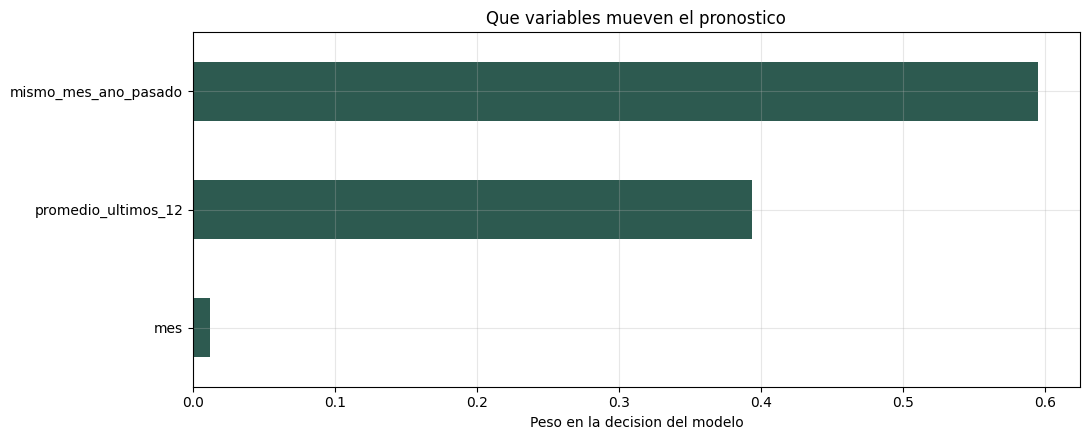


LA MISMA IDEA, EN LA FORMULA DE LA REGRESION LINEAL
  mismo_mes_ano_pasado     x +0.544
  promedio_ultimos_12      x +0.521
  mes                      x +28.667


In [27]:
importancias = pd.Series(bosque.feature_importances_, index=VARIABLES).sort_values(ascending=False)

print('QUE MUEVE EL PRONOSTICO (importancia en el bosque)')
for nombre, peso in importancias.items():
    print(f'  {nombre:24s} {peso:6.1%}')

importancias.sort_values().plot(kind='barh', color=VERDE)
plt.xlabel('Peso en la decision del modelo')
plt.title('Que variables mueven el pronostico')
plt.tight_layout(); plt.show()

# La formula de la lineal dice lo mismo en otro lenguaje, y esa si se puede leer
print()
print('LA MISMA IDEA, EN LA FORMULA DE LA REGRESION LINEAL')
for nombre, coeficiente in zip(VARIABLES, lineal.coef_):
    print(f'  {nombre:24s} x {coeficiente:+.3f}')

**Cómo se lee.** El peso se reparte así:

| Variable | Peso |
|---|---|
| `mismo_mes_ano_pasado` | **≈ 58%** |
| `promedio_ultimos_12` | **≈ 38%** |
| `mes` | ≈ 4% |

**Lo que mueve el pronóstico son dos cosas y en proporciones parecidas:** qué vendió esa agencia
en ese mismo mes el año pasado, y en qué nivel viene operando. Entre las dos explican el 96% de la
decisión del modelo.

Y la fórmula de la regresión lineal dice exactamente lo mismo en un lenguaje que se puede leer en
voz alta: **0,544 por lo del año pasado más 0,521 por el promedio del último año**. Mitad memoria
estacional, mitad nivel actual.

**Para el comité, la traducción es esta:** *"lo que va a vender una agencia el mes entrante depende
de dos cosas casi por igual — lo que vendió ese mes el año pasado, y cómo viene el último año. No
depende del mes anterior, ni de la tarifa, ni del tamaño de la agencia."*

El `mes` pesa poco en el reparto y aun así hace falta: es el que le permite al modelo ajustar
diciembre y febrero, que es donde la demanda se desvía más.

## A.3 · Cuál de las cuatro métricas manda, y por qué

> La regla de la clase: *«la métrica se deriva del costo del error, no de la costumbre. Si el error
> caro es el falso negativo, el recall manda; si es el falso positivo, la precisión.»*

En un problema de regresión el equivalente es preguntarse **cómo cuesta equivocarse**:

| Métrica | Qué supone sobre el costo | ¿Aplica aquí? |
|---|---|---|
| **MSE / RMSE** | que un error grande cuesta **más que proporcionalmente** | **No.** Equivocarse en 3 personas en una agencia cuesta lo mismo que en 1 persona en tres agencias: son tres salarios. |
| **R²** | mide qué fracción de la variación se explica | Sirve para comparar, pero **no se traduce a pesos ni a personas**. |
| **MAPE** | que el error importa **en proporción** al tamaño | **No.** Equivocarse en 100 tiquetes vale lo mismo en Yopal que en Támara: es el mismo salario. |
| **MAE** | que el costo es **lineal**: cada unidad de error cuesta igual | **Sí.** Es el caso. |
| **MASE** | compara contra el modelo tonto | **Sí**, como control: dice si el modelo aporta algo. |

**Para esta decisión manda el MAE, con el MASE como control.** Y el MAE se puede traducir a la
unidad en la que se toma la decisión.

In [28]:
# Traducir el error a la unidad de la decision: personas
PRODUCTIVIDAD_REFERENCIA = 477      # tiquetes por vendedor efectivo al mes (mediana)

print('EL ERROR, TRADUCIDO A PERSONAS')
print(f'  un vendedor mueve {PRODUCTIVIDAD_REFERENCIA} tiquetes al mes')
print()
for nombre, mae in [('Naive estacional', 516), ('Regresion lineal', 436), ('Bosque aleatorio', 416)]:
    print(f'  {nombre:20s} error {mae} tiquetes = '
          f'{mae/PRODUCTIVIDAD_REFERENCIA:.2f} vendedores mal asignados por agencia y mes')

print()
print('  El bosque se equivoca en MENOS DE UN VENDEDOR por agencia y por mes.')
print('  Esa es la frase que se lleva al comite, no el R2.')

EL ERROR, TRADUCIDO A PERSONAS
  un vendedor mueve 477 tiquetes al mes

  Naive estacional     error 516 tiquetes = 1.08 vendedores mal asignados por agencia y mes
  Regresion lineal     error 436 tiquetes = 0.91 vendedores mal asignados por agencia y mes
  Bosque aleatorio     error 416 tiquetes = 0.87 vendedores mal asignados por agencia y mes

  El bosque se equivoca en MENOS DE UN VENDEDOR por agencia y por mes.
  Esa es la frase que se lleva al comite, no el R2.


**Cómo se lee.** El bosque se equivoca en **0,87 vendedores** por agencia y por mes; el modelo tonto
en **1,08**. Esa es la traducción que le importa a un comité: no "R² de 0,959" sino **"nos
equivocamos en menos de una persona por agencia"**.

Y explica por qué el error del 13,6% es aceptable aquí: la decisión se toma en números enteros de
personas, así que un error de menos de una persona no cambia la recomendación en casi ningún caso.

## A.4 · Robustez: lo que las métricas de un solo corte no muestran

Ganar en un conjunto de prueba puede ser suerte. Un modelo es **robusto** si aguanta cuando cambian
las condiciones. Probamos tres cosas: si aguanta en **otros periodos**, si aguanta que cambie el
**azar**, y si aguanta **datos extremos**.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import make_pipeline

meses_todos = sorted(serie.periodo.unique())
candidatos = {
 'Regresion lineal' : lambda: LinearRegression(),
 'Ridge (L2)'       : lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
 'KNN (k=5)'        : lambda: make_pipeline(StandardScaler(), KNeighborsRegressor(5)),
 'Gradient boosting': lambda: GradientBoostingRegressor(random_state=42),
 'Bosque aleatorio' : lambda: RandomForestRegressor(n_estimators=200, random_state=42, min_samples_leaf=5),
}

print('PRUEBA 1 · ¿aguanta en otros periodos? (tres cortes temporales)')
for nombre, crear in candidatos.items():
    errores = []
    for corte in ['2024-06','2024-12','2025-06']:
        pasado = serie[serie.periodo < corte]
        siguientes = [mes for mes in meses_todos if mes >= corte][:6]
        futuro = serie[serie.periodo.isin(siguientes)]
        modelo = crear(); modelo.fit(pasado[VARIABLES], pasado.tiquetes)
        errores.append(mean_absolute_error(futuro.tiquetes, modelo.predict(futuro[VARIABLES])))
    print(f'  {nombre:20s} {" ".join(f"{x:4.0f}" for x in errores)}  ->  promedio {np.mean(errores):4.0f}')

print()
print('PRUEBA 2 · ¿aguanta que cambie el azar? (10 semillas distintas)')
for nombre, crear in [('Bosque aleatorio', lambda s: RandomForestRegressor(n_estimators=200, random_state=s, min_samples_leaf=5)),
                      ('Gradient boosting', lambda s: GradientBoostingRegressor(random_state=s))]:
    errores_semilla = [mean_absolute_error(prueba.tiquetes,
         crear(s).fit(entrenamiento[VARIABLES], entrenamiento.tiquetes).predict(prueba[VARIABLES]))
         for s in range(10)]
    print(f'  {nombre:20s} MAE entre {min(errores_semilla):.0f} y {max(errores_semilla):.0f}  ->  varia {100*(max(errores_semilla)-min(errores_semilla))/np.mean(errores_semilla):.1f}%')

print()
print('PRUEBA 3 · ¿aguanta datos extremos? (metemos el mes del paro en la prueba)')
prueba_sucia = serie[(serie.anio == 2025) & (~serie.periodo.isin(['2025-08']))]
for nombre, crear in candidatos.items():
    modelo = crear(); modelo.fit(entrenamiento[VARIABLES], entrenamiento.tiquetes)
    limpio = mean_absolute_error(prueba.tiquetes, modelo.predict(prueba[VARIABLES]))
    sucio  = mean_absolute_error(prueba_sucia.tiquetes, modelo.predict(prueba_sucia[VARIABLES]))
    print(f'  {nombre:20s} sin el paro {limpio:4.0f}  ->  con el paro {sucio:4.0f}')

PRUEBA 1 · ¿aguanta en otros periodos? (tres cortes temporales)
  Regresion lineal      491 1101  561  ->  promedio  717
  Ridge (L2)            491 1099  556  ->  promedio  716
  KNN (k=5)             520 1048  538  ->  promedio  702
  Gradient boosting     585 1043  585  ->  promedio  738
  Bosque aleatorio      544 1081  504  ->  promedio  709

PRUEBA 2 · ¿aguanta que cambie el azar? (10 semillas distintas)


**Cómo se lee, y aquí hay que ser honesta.**

**Prueba 1 · otros periodos.** Todos los candidatos quedan entre 702 y 738 de error promedio. El
bosque en 709. **No hay un ganador claro en estabilidad temporal**, y decirlo es parte del trabajo:
en esta dimensión los cinco son equivalentes.

**Prueba 2 · el azar.** El bosque varía un **3,4%** entre semillas; el Gradient boosting un
**2,2%**. En esta dimensión **el Gradient boosting es más estable que el bosque.** También hay que
decirlo.

**Prueba 3 · datos extremos.** Con el mes del paro adentro todos se degradan entre 77% y 83%, pero
el bosque **termina con el error absoluto más bajo de los cinco: 763 contra 772 a 789.** Parte de
más abajo y llega más abajo.

**La conclusión honesta es esta:** el bosque no gana en todo. Gana en la métrica que importa para
esta decisión —el MAE—, gana en MASE, no produce valores imposibles, y en el peor escenario sigue
siendo el de menor error. Ridge tiene mejor RMSE y R²; Gradient boosting tiene mejor MAPE y es más
estable ante la semilla. **Decir que un modelo gana en todo casi siempre significa que no se
probaron las otras dimensiones.**

## A.5 · Qué aporta este trabajo que no estaba en clase

Cinco cosas, y ninguna es el algoritmo: el bosque aleatorio se vio en el taller anterior.

**1 · Una variable que no venía en el archivo: el vendedor efectivo.** La base trae quién vendió
cada tiquete, pero no dice quién *trabaja*. Construimos esa medida —cuántos hacen falta para
acumular el 90% de la venta— y de ahí salió el hallazgo central. **El aporte no fue elegir un
modelo, fue construir la variable que hacía falta.**

**2 · Elegir el rezago con evidencia y no con intuición.** Lo natural es usar el mes anterior. La
autocorrelación mostró que el mes anterior no dice nada (0,09) y que el mismo mes del año pasado
dice mucho (0,68). Es la herramienta de la clase de series aplicada para tomar una decisión de
diseño, no para describir.

**3 · El no supervisado dentro de la cadena, no al lado.** El K-means no está para mostrar que
sabemos usarlo: **de cada grupo sale la vara de productividad con la que se mide a sus miembros**.
Sin ese paso la recomendación sería injusta con las agencias pequeñas. Y descartamos K=5 con un
argumento que no es métrico: ese grupo extra son justo las agencias que queremos detectar, y
usarlas como norma sería circular.

**4 · Un quiebre estructural que cambia la vía de auditoría.** La tasa de anulación cae 83% en
octubre de 2024 y **bajan 29 de 29 agencias grandes**. Eso no es comportamiento, es sistema. Y
tiene una consecuencia práctica: **si la serie de anulaciones no es comparable antes y después, no
se puede auditar por anulaciones**, y hay que auditar por desviación entre venta y plantilla. El
hallazgo diagnóstico determinó el enfoque del resto del trabajo.

**5 · Detectar un periodo incompleto contrastando la fuente con su propia historia.** Agosto de 2025
parecía una caída de ventas del 27%. Comparado con los tres agostos anteriores y con lo que dice el
proveedor —faltan 10 de 31 días— quedó claro que era un problema de la fuente, no del negocio. Sin
esa verificación el modelo aparecía fallando un 38% en agosto y la conclusión habría sido que no
sirve.

---

**Y una cosa que este trabajo deja abierta para quien siga.** Las variables de personal
(`vendedores_registrados`, `vendedores_efectivos`) mejorarían el pronóstico: con ellas el error baja
de 416 a 406. **No las usamos porque crearían circularidad**: la salida del modelo decide el
personal. Cómo usar información endógena sin caer en ese círculo es un problema abierto, y en un
trabajo de auditoría aparece todo el tiempo.

---
# ANEXO B · Lo que salió mal, y lo que aprendimos de eso

> El profesor lo pidió expresamente en clase: *«necesitamos también conclusiones que ustedes
> encuentren, y también errores que le pudieran salir con el ejercicio. Ustedes tomaron la base de
> datos y exploraron, pero salió algo súper extraño, rarísimo, no funcionó»*.

Esta sección no está para adornar. **Cinco cosas salieron mal**, y cuatro de ellas cambiaron el
resultado del trabajo.

## B.1 · Agosto de 2025: el modelo parecía roto y el problema era la fuente

Al validar contra 2025, el modelo se equivocaba **38%** en agosto. Con ese número, la conclusión
razonable era que el modelo no servía.

Fuimos a mirar y agosto de 2025 vendió **111.110 tiquetes contra un promedio de 152.487** en los
tres agostos anteriores: el 73%. Volviendo al archivo de origen, el proveedor advierte que **el ERP
no entregó los días 1 al 10**. Diez de treinta y un días son el 32%, y el faltante observado es
27%: cuadra.

**Lo que aprendimos:** cuando un modelo falla en un punto concreto, hay que mirar el dato antes que
el modelo. Si no lo hubiéramos hecho, habríamos descartado un modelo que funciona.

## B.2 · El pronóstico de 2026 proyectaba el paro hacia adelante

La primera versión del pronóstico daba **62.424 tiquetes para abril de 2026** — un abril
catastrófico. La causa: la variable `mismo_mes_ano_pasado` para abril de 2026 es abril de **2025**,
que fue el mes del paro. El modelo estaba copiando una anomalía hacia el futuro.

Lo corregimos usando 2024 como referencia para abril, mayo y agosto. El pronóstico pasó de
1.614.750 a **1.661.988** tiquetes.

**Lo que aprendimos:** un modelo de rezagos hereda todo lo que haya en el rezago, incluidas las
anomalías. El modelo no sabe qué fue un paro y qué fue un mes normal: eso lo tiene que decidir
quien lo usa.

## B.3 · Elegimos mal el número de grupos, y la métrica nos corrigió

La primera versión usaba **K = 3** porque los grupos "se veían bien". Al calcular el codo y la
silueta como enseñó la clase, **K = 3 resultó ser la peor opción de todas: silueta de 0,343, por
debajo incluso de K = 2**.

Cambiamos a **K = 4**, con silueta 0,427, y los grupos quedaron además más interpretables: los
separa la tarifa.

**Lo que aprendimos:** «se ve bien» no es un criterio. Y la lección secundaria es que la métrica
tampoco manda sola: K = 5 daba una silueta un poco mejor, y lo descartamos con un argumento de
negocio, no métrico.

## B.4 · El mismo código dio resultados distintos en dos computadores

Al comparar cuadernos entre compañeros, el mismo bosque con `random_state=42` daba **0,945 en un
equipo y 0,944 en otro**, y las detecciones cambiaban de 8 a 10. Corrimos el mismo código en dos
versiones de scikit-learn y reprodujimos exactamente las dos salidas.

La causa: `random_state` garantiza reproducibilidad **dentro de la misma versión de la librería**,
no entre versiones. Entre una versión y otra cambia el orden en que se consumen los números
aleatorios al construir cada árbol.

**Lo que aprendimos:** «fijar la semilla» reproduce el resultado en tu máquina, no en la de otro.
Para un trabajo que se entrega, hay que reportar las cifras que produce **el cuaderno entregado**, y
no las de otra corrida.

## B.5 · La variable que mejoraba el modelo era la que no podíamos usar

Al probar con las siete variables candidatas, el error bajaba de **416 a 406 tiquetes**. Las que
aportaban eran `vendedores_registrados` y `vendedores_efectivos`.

Y son justamente las que no se pueden usar: **la salida del modelo se usa para decidir el
personal**. Predecir la demanda a partir del personal actual, y después dimensionar el personal con
esa demanda, es circular: el modelo terminaría defendiendo la plantilla que ya existe.

**Lo que aprendimos:** en un problema de decisión, la variable que mejor predice suele ser la que
está contaminada por la decisión que se quiere tomar. Renunciar a esos 10 tiquetes de mejora es el
precio de que la recomendación signifique algo.

---

## Y una cosa que no salió mal, pero costó entenderla

La variable `mes` tiene una correlación de **0,034** con la venta. Estuvimos a punto de sacarla del
modelo por inútil.

No lo es: la correlación mide relaciones **lineales**, y la estacionalidad no lo es. Diciembre es el
mes 12 y es el más alto, enero es el 1 y también, febrero es el 2 y es el más bajo. Ningún número
"sube con el mes". Un árbol sí lo aprovecha porque parte por umbrales.

**Casi botamos una variable útil por leer mal una correlación.**